# Análise Exploratória de Dados (EDA)

## Tech Challenge Fase 3 - Machine Learning Engineering

**Objetivo:** Analisar dados de voos nos EUA para identificar padrões de atrasos e preparar os dados para modelagem.

### Estrutura da Análise:
1. Entendimento e Limpeza Inicial dos Dados
2. Análise Univariada
3. Análise Bivariada
4. Análise Multivariada
5. Análise de Motivos (Drill-down)

In [1]:
# Imports e Configurações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Cores para gráficos
COLORS = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


In [2]:
df_airline = pd.read_csv('D:/5. Academia/4. Machine Learning Engineering - FIAP/projeto_3/data/raw/airlines.csv')
df_airline.info()
display(df_airline)

# Explicação do dataset:
# - IATA_CODE: Código da companhia aérea (ex: AA, DL, etc.)
# - AIRLINE: Nome da companhia aérea (ex: American Airlines, Delta Air Lines, etc.)

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   IATA_CODE  14 non-null     str  
 1   AIRLINE    14 non-null     str  
dtypes: str(2)
memory usage: 669.0 bytes


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways
5,OO,Skywest Airlines Inc.
6,AS,Alaska Airlines Inc.
7,NK,Spirit Air Lines
8,WN,Southwest Airlines Co.
9,DL,Delta Air Lines Inc.


In [3]:
df_airports = pd.read_csv('D:/5. Academia/4. Machine Learning Engineering - FIAP/projeto_3/data/raw/airports.csv')
df_airports.info()
display(df_airports)

# Explicação do dataset:
# - IATA_CODE: Código do aeroporto (ex: ATL, LAX, etc.)
# - AIRPORT: Nome do aeroporto (ex: Hartsfield-Jackson Atlanta International Airport, Los Angeles International Airport, etc.)
# - CITY: Cidade onde o aeroporto está localizado (ex: Atlanta, Los Angeles, etc.)
# - COUNTRY: País onde o aeroporto está localizado (ex: Estados Unidos, etc.)
# - LATITUDE: Latitude do aeroporto
# - LONGITUDE: Longitude do aeroporto

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IATA_CODE  322 non-null    str    
 1   AIRPORT    322 non-null    str    
 2   CITY       322 non-null    str    
 3   STATE      322 non-null    str    
 4   COUNTRY    322 non-null    str    
 5   LATITUDE   319 non-null    float64
 6   LONGITUDE  319 non-null    float64
dtypes: float64(2), str(5)
memory usage: 33.4 KB


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65,-75.44
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41,-99.68
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04,-106.61
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.45,-98.42
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.54,-84.19
...,...,...,...,...,...,...,...
317,WRG,Wrangell Airport,Wrangell,AK,USA,56.48,-132.37
318,WYS,Westerly State Airport,West Yellowstone,MT,USA,44.69,-111.12
319,XNA,Northwest Arkansas Regional Airport,Fayetteville/Springdale/Rogers,AR,USA,36.28,-94.31
320,YAK,Yakutat Airport,Yakutat,AK,USA,59.50,-139.66


In [4]:
df_flights = pd.read_csv('D:/5. Academia/4. Machine Learning Engineering - FIAP/projeto_3/data/raw/flights.csv')
df_flights.info()
display(df_flights)

# Explicação do dataset:
# - YEAR: Ano do voo (ex: 2015, 2016, etc.)
# - MONTH: Mês do voo (ex: 1, 2, ..., 12)
# - DAY: Dia do voo (ex: 1, 2, ..., 31)
# - DAY_OF_WEEK: Dia da semana do voo (ex: 1 para segunda-feira, 2 para terça-feira, ..., 7 para domingo)
# - AIRLINE: Código da companhia aérea (ex: AA, DL, etc.)
# - FLIGHT_NUMBER: Número do voo (ex: 100, 200, etc.)
# - TAIL_NUMBER: Número de cauda da aeronave (ex: N12345, etc.)
# - ORIGIN_AIRPORT: Código do aeroporto de origem (ex: ATL, LAX, etc.)
# - DESTINATION_AIRPORT: Código do aeroporto de destino (ex: ATL, LAX, etc.)
# - SCHEDULED_DEPARTURE: Horário programado de partida (ex: 700 para 7:00, 1330 para 13:30, etc.)
# - DEPARTURE_TIME: Horário real de partida (ex: 715 para 7:15, 1345 para 13:45, etc.)
# - DEPARTURE_DELAY: Atraso na partida em minutos (ex: 15 para 15 minutos de atraso, -5 para 5 minutos adiantado, etc.)
# - TAXI_OUT : Tempo de taxiamento para decolagem em minutos (ex: 10 para 10 minutos, etc.)
# - WHEELS_OFF: Horário em que as rodas do avião saíram do chão (ex: 720 para 7:20, etc.)
# - SCHEDULED_TIME: Tempo programado de voo em minutos (ex: 120 para 2 horas, etc.)
# - ELAPSED_TIME: Tempo real de voo em minutos (ex: 130 para 2 horas e 10 minutos, etc.)
# - AIR_TIME: Tempo real de voo no ar em minutos (ex: 110 para 1 hora e 50 minutos, etc.)
# - DISTANCE: Distância do voo em milhas (ex: 500 para 500 milhas, etc.)
# - WHEELS_ON: Horário em que as rodas do avião tocaram o chão no destino (ex: 900 para 9:00, etc.)
# - TAXI_IN: Tempo de taxiamento para estacionamento em minutos (ex: 15 para 15 minutos, etc.)
# - SCHEDULED_ARRIVAL: Horário programado de chegada (ex: 900 para 9:00, etc.)
# - ARRIVAL_TIME: Horário real de chegada (ex: 915 para 9:15, etc.)
# - ARRIVAL_DELAY: Atraso na chegada em minutos (ex: 15 para 15 minutos de atraso, -5 para 5 minutos adiantado, etc.)
# - DIVERTED: Indicador de voo desviado (0 para não desviado, 1 para desviado)
# - CANCELLED: Indicador de voo cancelado (0 para não cancelado, 1 para cancelado)
# - CANCELLATION_REASON: Razão do cancelamento (A para condições climáticas adversas, B para problemas de segurança, C para problemas operacionais, D para outros motivos, etc.)
# - AIR_SYSTEM_DELAY: Atraso causado por problemas no sistema aéreo em minutos (ex: 20 para 20 minutos, etc.)
# - SECURITY_DELAY: Atraso causado por problemas de segurança em minutos (ex: 10 para 10 minutos, etc.)
# - AIRLINE_DELAY: Atraso causado por problemas da companhia aérea em minutos (ex: 15 para 15 minutos, etc.)
# - LATE_AIRCRAFT_DELAY: Atraso causado por atrasos de aeronaves anteriores em minutos (ex: 25 para 25 minutos, etc.)
# - WEATHER_DELAY: Atraso causado por condições climáticas adversas em minutos (ex: 30 para 30 minutos, etc.)

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24  CANCELLED

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.00,-11.00,21.00,15.00,205.00,194.00,169.00,1448,404.00,4.00,430,408.00,-22.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.00,-8.00,12.00,14.00,280.00,279.00,263.00,2330,737.00,4.00,750,741.00,-9.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.00,-2.00,16.00,34.00,286.00,293.00,266.00,2296,800.00,11.00,806,811.00,5.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.00,-5.00,15.00,30.00,285.00,281.00,258.00,2342,748.00,8.00,805,756.00,-9.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.00,-1.00,11.00,35.00,235.00,215.00,199.00,1448,254.00,5.00,320,259.00,-21.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5819074,2015,12,31,4,B6,688,N657JB,LAX,BOS,2359,2355.00,-4.00,22.00,17.00,320.00,298.00,272.00,2611,749.00,4.00,819,753.00,-26.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819075,2015,12,31,4,B6,745,N828JB,JFK,PSE,2359,2355.00,-4.00,17.00,12.00,227.00,215.00,195.00,1617,427.00,3.00,446,430.00,-16.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819076,2015,12,31,4,B6,1503,N913JB,JFK,SJU,2359,2350.00,-9.00,17.00,7.00,221.00,222.00,197.00,1598,424.00,8.00,440,432.00,-8.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819077,2015,12,31,4,B6,333,N527JB,MCO,SJU,2359,2353.00,-6.00,10.00,3.00,161.00,157.00,144.00,1189,327.00,3.00,340,330.00,-10.00,0,0,NaN,NaN,NaN,NaN,NaN,NaN


---
# 1. Entendimento e Limpeza Inicial dos Dados

Nesta seção, vamos:
- Verificar tipos de dados
- Identificar valores nulos
- Calcular estatísticas descritivas
- Realizar limpezas necessárias

In [5]:
# 1.1 Verificação dos Tipos de Dados
print('='*60)
print('ESTRUTURA DO DATASET DE VOOS')
print('='*60)
print(f'\nDimensões: {df_flights.shape[0]:,} linhas x {df_flights.shape[1]} colunas')
print(f'Uso de memória: {df_flights.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print('\n' + '-'*60)
print('TIPOS DE DADOS:')
print('-'*60)
for col in df_flights.columns:
    print(f'{col:25} -> {df_flights[col].dtype}')

ESTRUTURA DO DATASET DE VOOS

Dimensões: 5,819,079 linhas x 31 colunas
Uso de memória: 1896.51 MB

------------------------------------------------------------
TIPOS DE DADOS:
------------------------------------------------------------
YEAR                      -> int64
MONTH                     -> int64
DAY                       -> int64
DAY_OF_WEEK               -> int64
AIRLINE                   -> str
FLIGHT_NUMBER             -> int64
TAIL_NUMBER               -> str
ORIGIN_AIRPORT            -> object
DESTINATION_AIRPORT       -> object
SCHEDULED_DEPARTURE       -> int64
DEPARTURE_TIME            -> float64
DEPARTURE_DELAY           -> float64
TAXI_OUT                  -> float64
WHEELS_OFF                -> float64
SCHEDULED_TIME            -> float64
ELAPSED_TIME              -> float64
AIR_TIME                  -> float64
DISTANCE                  -> int64
WHEELS_ON                 -> float64
TAXI_IN                   -> float64
SCHEDULED_ARRIVAL         -> int64
ARRIVAL_TIME

ANÁLISE DE VALORES NULOS

Total de colunas com valores nulos: 18
Total de registros: 5,819,079



Total de colunas com valores nulos: 18
Total de registros: 5,819,079




,Nulos,Percentual (%),Tipo
CANCELLATION_REASON,5729195,98.46,str
SECURITY_DELAY,4755640,81.72,float64
AIR_SYSTEM_DELAY,4755640,81.72,float64
LATE_AIRCRAFT_DELAY,4755640,81.72,float64
WEATHER_DELAY,4755640,81.72,float64
AIRLINE_DELAY,4755640,81.72,float64
ARRIVAL_DELAY,105071,1.81,float64
ELAPSED_TIME,105071,1.81,float64
AIR_TIME,105071,1.81,float64
TAXI_IN,92513,1.59,float64


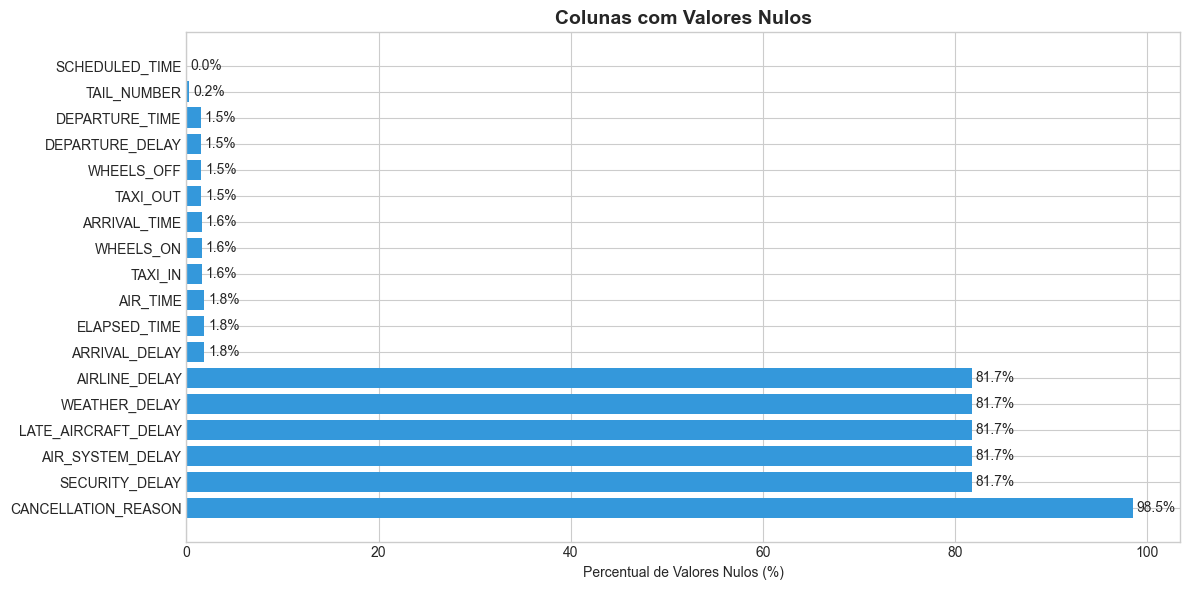

In [6]:
# 1.2 Identificação de Valores Nulos
print('='*60)
print('ANÁLISE DE VALORES NULOS')
print('='*60)

null_analysis = pd.DataFrame({
    'Nulos': df_flights.isnull().sum(),
    'Percentual (%)': (df_flights.isnull().sum() / len(df_flights) * 100).round(2),
    'Tipo': df_flights.dtypes
})
null_analysis = null_analysis[null_analysis['Nulos'] > 0].sort_values('Percentual (%)', ascending=False)

print(f'\nTotal de colunas com valores nulos: {len(null_analysis)}')
print(f'Total de registros: {len(df_flights):,}')
print('\n')
display(null_analysis)

# Visualização dos valores nulos
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(null_analysis.index, null_analysis['Percentual (%)'], color=COLORS[0])
ax.set_xlabel('Percentual de Valores Nulos (%)')
ax.set_title('Colunas com Valores Nulos', fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

In [7]:
# 1.2.1 Entendendo o contexto dos valores nulos
print('='*60)
print('CONTEXTO DOS VALORES NULOS')
print('='*60)

# Voos cancelados x valores nulos
print('\n📌 VOOS CANCELADOS:')
cancelled_flights = df_flights[df_flights['CANCELLED'] == 1]
print(f'   Total de voos cancelados: {len(cancelled_flights):,} ({len(cancelled_flights)/len(df_flights)*100:.2f}%)')

# Verificar se nulos de DEPARTURE_TIME coincidem com cancelamentos
null_departure = df_flights[df_flights['DEPARTURE_TIME'].isnull()]
print(f'   Voos sem DEPARTURE_TIME: {len(null_departure):,}')
print(f'   Destes, quantos foram cancelados: {null_departure["CANCELLED"].sum():,}')

# Voos desviados
print('\n📌 VOOS DESVIADOS:')
diverted_flights = df_flights[df_flights['DIVERTED'] == 1]
print(f'   Total de voos desviados: {len(diverted_flights):,} ({len(diverted_flights)/len(df_flights)*100:.2f}%)')

# Colunas de delay - nulos quando não há atraso significativo
print('\n📌 COLUNAS DE MOTIVO DE ATRASO (AIR_SYSTEM_DELAY, etc.):')
delay_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
for col in delay_cols:
    non_null = df_flights[col].notna().sum()
    print(f'   {col}: {non_null:,} registros com valor ({non_null/len(df_flights)*100:.2f}%)')

CONTEXTO DOS VALORES NULOS

📌 VOOS CANCELADOS:
   Total de voos cancelados: 89,884 (1.54%)
   Voos sem DEPARTURE_TIME: 86,153
   Destes, quantos foram cancelados: 86,153

📌 VOOS DESVIADOS:
   Total de voos desviados: 15,187 (0.26%)

📌 COLUNAS DE MOTIVO DE ATRASO (AIR_SYSTEM_DELAY, etc.):
   AIR_SYSTEM_DELAY: 1,063,439 registros com valor (18.28%)
   SECURITY_DELAY: 1,063,439 registros com valor (18.28%)
   AIRLINE_DELAY: 1,063,439 registros com valor (18.28%)
   LATE_AIRCRAFT_DELAY: 1,063,439 registros com valor (18.28%)
   WEATHER_DELAY: 1,063,439 registros com valor (18.28%)


In [8]:
# 1.3 Estatísticas Descritivas
print('='*60)
print('ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS')
print('='*60)

# Variáveis principais para análise
main_numeric_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE', 'SCHEDULED_TIME', 
                     'ELAPSED_TIME', 'AIR_TIME', 'TAXI_OUT', 'TAXI_IN']

stats = df_flights[main_numeric_cols].describe().T
stats['missing'] = df_flights[main_numeric_cols].isnull().sum()
stats['missing_%'] = (stats['missing'] / len(df_flights) * 100).round(2)

display(stats.style.format('{:.2f}').background_gradient(cmap='Blues', subset=['mean', 'std']))

ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max,missing,missing_%
DEPARTURE_DELAY,5732926.00,9.37,37.08,-82.00,-5.00,-2.00,7.00,1988.00,86153.00,1.48
ARRIVAL_DELAY,5714008.00,4.41,39.27,-87.00,-13.00,-5.00,8.00,1971.00,105071.00,1.81
DISTANCE,5819079.00,822.36,607.78,21.00,373.00,647.00,1062.00,4983.00,0.00,0.00
SCHEDULED_TIME,5819073.00,141.69,75.21,18.00,85.00,123.00,173.00,718.00,6.00,0.00
ELAPSED_TIME,5714008.00,137.01,74.21,14.00,82.00,118.00,168.00,766.00,105071.00,1.81
AIR_TIME,5714008.00,113.51,72.23,7.00,60.00,94.00,144.00,690.00,105071.00,1.81
TAXI_OUT,5730032.00,16.07,8.90,1.00,11.00,14.00,19.00,225.00,89047.00,1.53
TAXI_IN,5726566.00,7.43,5.64,1.00,4.00,6.00,9.00,248.00,92513.00,1.59


In [9]:
# 1.3.1 Estatísticas Descritivas - Variáveis Categóricas
print('='*60)
print('ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS CATEGÓRICAS')
print('='*60)

cat_cols = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'CANCELLATION_REASON']

for col in cat_cols:
    print(f'\n📊 {col}:')
    print(f'   Valores únicos: {df_flights[col].nunique()}')
    print(f'   Mais frequente: {df_flights[col].mode().values[0] if not df_flights[col].mode().empty else "N/A"}')
    print(f'   Valores nulos: {df_flights[col].isnull().sum()}')

ESTATÍSTICAS DESCRITIVAS - VARIÁVEIS CATEGÓRICAS

📊 AIRLINE:
   Valores únicos: 14
   Mais frequente: WN
   Valores nulos: 0

📊 ORIGIN_AIRPORT:
   Valores únicos: 930
   Mais frequente: WN
   Valores nulos: 0

📊 ORIGIN_AIRPORT:
   Valores únicos: 930
   Mais frequente: ATL
   Valores nulos: 0

📊 DESTINATION_AIRPORT:
   Valores únicos: 930
   Mais frequente: ATL
   Valores nulos: 0

📊 DESTINATION_AIRPORT:
   Valores únicos: 930
   Mais frequente: ATL
   Valores nulos: 0

📊 CANCELLATION_REASON:
   Valores únicos: 4
   Mais frequente: B
   Valores nulos: 5729195
   Mais frequente: ATL
   Valores nulos: 0

📊 CANCELLATION_REASON:
   Valores únicos: 4
   Mais frequente: B
   Valores nulos: 5729195


In [10]:
# 1.4 Criação de Variáveis Auxiliares para Análise
print('='*60)
print('CRIAÇÃO DE VARIÁVEIS AUXILIARES')
print('='*60)

# Criar cópia do dataframe para não modificar o original
df = df_flights.copy()

# 1. Variável binária de atraso (>= 15 minutos é considerado atraso oficial)
df['IS_DELAYED'] = (df['ARRIVAL_DELAY'] >= 15).astype(int)

# 2. Categorias de atraso
def categorize_delay(delay):
    if pd.isna(delay):
        return 'Sem Info'
    elif delay < 0:
        return 'Adiantado'
    elif delay == 0:
        return 'No Horário'
    elif delay < 15:
        return 'Atraso Leve (<15min)'
    elif delay < 60:
        return 'Atraso Moderado (15-60min)'
    elif delay < 120:
        return 'Atraso Significativo (1-2h)'
    else:
        return 'Atraso Severo (>2h)'

df['DELAY_CATEGORY'] = df['ARRIVAL_DELAY'].apply(categorize_delay)

# 3. Período do dia baseado no horário de partida
def get_period(hour):
    if pd.isna(hour):
        return 'Sem Info'
    hour = int(hour) // 100  # Converter HHMM para hora
    if 5 <= hour < 12:
        return 'Manhã (5h-12h)'
    elif 12 <= hour < 17:
        return 'Tarde (12h-17h)'
    elif 17 <= hour < 21:
        return 'Noite (17h-21h)'
    else:
        return 'Madrugada (21h-5h)'

df['PERIOD'] = df['SCHEDULED_DEPARTURE'].apply(get_period)

# 4. Hora do dia (extraída do horário programado)
df['HOUR'] = df['SCHEDULED_DEPARTURE'].apply(lambda x: int(x) // 100 if pd.notna(x) else None)

# 5. Criar coluna de data
df['DATE'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']])

# 6. Nome do mês
month_names = {1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 5: 'Maio', 6: 'Junho',
               7: 'Julho', 8: 'Agosto', 9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'}
df['MONTH_NAME'] = df['MONTH'].map(month_names)

# 7. Nome do dia da semana
day_names = {1: 'Segunda', 2: 'Terça', 3: 'Quarta', 4: 'Quinta', 5: 'Sexta', 6: 'Sábado', 7: 'Domingo'}
df['DAY_NAME'] = df['DAY_OF_WEEK'].map(day_names)

# 8. Converter colunas de aeroporto para string (alguns valores são inteiros)
df['ORIGIN_AIRPORT'] = df['ORIGIN_AIRPORT'].astype(str)
df['DESTINATION_AIRPORT'] = df['DESTINATION_AIRPORT'].astype(str)

# 9. Criar rota
df['ROUTE'] = df['ORIGIN_AIRPORT'] + ' → ' + df['DESTINATION_AIRPORT']

print('✅ Variáveis criadas:')
print('   - IS_DELAYED: Indicador binário de atraso (>= 15 min)')
print('   - DELAY_CATEGORY: Categoria do atraso')
print('   - PERIOD: Período do dia')
print('   - HOUR: Hora do dia')
print('   - DATE: Data completa')
print('   - MONTH_NAME: Nome do mês')
print('   - DAY_NAME: Nome do dia da semana')
print('   - ROUTE: Rota (Origem → Destino)')

print(f'\nNovo shape do dataframe: {df.shape}')

CRIAÇÃO DE VARIÁVEIS AUXILIARES
✅ Variáveis criadas:
   - IS_DELAYED: Indicador binário de atraso (>= 15 min)
   - DELAY_CATEGORY: Categoria do atraso
   - PERIOD: Período do dia
   - HOUR: Hora do dia
   - DATE: Data completa
   - MONTH_NAME: Nome do mês
   - DAY_NAME: Nome do dia da semana
   - ROUTE: Rota (Origem → Destino)

Novo shape do dataframe: (5819079, 39)
✅ Variáveis criadas:
   - IS_DELAYED: Indicador binário de atraso (>= 15 min)
   - DELAY_CATEGORY: Categoria do atraso
   - PERIOD: Período do dia
   - HOUR: Hora do dia
   - DATE: Data completa
   - MONTH_NAME: Nome do mês
   - DAY_NAME: Nome do dia da semana
   - ROUTE: Rota (Origem → Destino)

Novo shape do dataframe: (5819079, 39)


In [11]:
# 1.5 Enriquecimento dos Dados (Merge com Airlines e Airports)
print('='*60)
print('ENRIQUECIMENTO DOS DADOS')
print('='*60)

# Garantir que IATA_CODE nos airports também é string para o merge funcionar
df_airports['IATA_CODE'] = df_airports['IATA_CODE'].astype(str)

# Verificar colunas do df_airline
print(f'Colunas df_airline: {df_airline.columns.tolist()}')

# Merge com airlines para ter nome da companhia
# df_airline tem IATA_CODE e AIRLINE (nome da companhia)
df = df.merge(df_airline, left_on='AIRLINE', right_on='IATA_CODE', how='left', suffixes=('', '_FULL'))
# Após o merge, teremos AIRLINE (código original) e AIRLINE_FULL (nome completo)
df.rename(columns={'AIRLINE_FULL': 'AIRLINE_NAME'}, inplace=True)
df.drop(columns=['IATA_CODE'], inplace=True, errors='ignore')

print(f'Colunas após merge com airlines: {[c for c in df.columns if "AIRLINE" in c]}')

# Merge com airports para origem
df = df.merge(df_airports[['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'LATITUDE', 'LONGITUDE']], 
              left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left')
df.rename(columns={'AIRPORT': 'ORIGIN_AIRPORT_NAME', 'CITY': 'ORIGIN_CITY', 
                   'STATE': 'ORIGIN_STATE', 'LATITUDE': 'ORIGIN_LAT', 'LONGITUDE': 'ORIGIN_LON'}, inplace=True)
df.drop(columns=['IATA_CODE'], inplace=True, errors='ignore')

# Merge com airports para destino
df = df.merge(df_airports[['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'LATITUDE', 'LONGITUDE']], 
              left_on='DESTINATION_AIRPORT', right_on='IATA_CODE', how='left')
df.rename(columns={'AIRPORT': 'DEST_AIRPORT_NAME', 'CITY': 'DEST_CITY', 
                   'STATE': 'DEST_STATE', 'LATITUDE': 'DEST_LAT', 'LONGITUDE': 'DEST_LON'}, inplace=True)
df.drop(columns=['IATA_CODE'], inplace=True, errors='ignore')

print(f'✅ Dados enriquecidos!')
print(f'   Shape final: {df.shape}')
print(f'\nNovas colunas adicionadas:')
print('   - AIRLINE_NAME: Nome completo da companhia aérea')
print('   - ORIGIN_AIRPORT_NAME, ORIGIN_CITY, ORIGIN_STATE, ORIGIN_LAT, ORIGIN_LON')
print('   - DEST_AIRPORT_NAME, DEST_CITY, DEST_STATE, DEST_LAT, DEST_LON')

ENRIQUECIMENTO DOS DADOS
Colunas df_airline: ['IATA_CODE', 'AIRLINE']
Colunas após merge com airlines: ['AIRLINE', 'AIRLINE_DELAY', 'AIRLINE_NAME']
Colunas após merge com airlines: ['AIRLINE', 'AIRLINE_DELAY', 'AIRLINE_NAME']
✅ Dados enriquecidos!
   Shape final: (5819079, 50)

Novas colunas adicionadas:
   - AIRLINE_NAME: Nome completo da companhia aérea
   - ORIGIN_AIRPORT_NAME, ORIGIN_CITY, ORIGIN_STATE, ORIGIN_LAT, ORIGIN_LON
   - DEST_AIRPORT_NAME, DEST_CITY, DEST_STATE, DEST_LAT, DEST_LON
✅ Dados enriquecidos!
   Shape final: (5819079, 50)

Novas colunas adicionadas:
   - AIRLINE_NAME: Nome completo da companhia aérea
   - ORIGIN_AIRPORT_NAME, ORIGIN_CITY, ORIGIN_STATE, ORIGIN_LAT, ORIGIN_LON
   - DEST_AIRPORT_NAME, DEST_CITY, DEST_STATE, DEST_LAT, DEST_LON


In [12]:
# 1.6 Resumo Final do Dataset
print('='*60)
print('RESUMO FINAL DO DATASET APÓS PREPARAÇÃO')
print('='*60)

# Filtrar apenas voos não cancelados para análise de atrasos
df_valid = df[df['CANCELLED'] == 0].copy()

print(f'\n📊 ESTATÍSTICAS GERAIS:')
print(f'   Total de voos: {len(df):,}')
print(f'   Voos válidos (não cancelados): {len(df_valid):,} ({len(df_valid)/len(df)*100:.2f}%)')
print(f'   Voos cancelados: {len(df) - len(df_valid):,} ({(len(df) - len(df_valid))/len(df)*100:.2f}%)')
print(f'   Voos desviados: {df["DIVERTED"].sum():,} ({df["DIVERTED"].sum()/len(df)*100:.2f}%)')

print(f'\n📌 ATRASOS (considerando apenas voos válidos):')
print(f'   Voos com atraso >= 15min: {df_valid["IS_DELAYED"].sum():,} ({df_valid["IS_DELAYED"].mean()*100:.2f}%)')
print(f'   Atraso médio na chegada: {df_valid["ARRIVAL_DELAY"].mean():.2f} minutos')
print(f'   Atraso mediano na chegada: {df_valid["ARRIVAL_DELAY"].median():.2f} minutos')

print(f'\n📅 PERÍODO DOS DADOS:')
print(f'   De: {df["DATE"].min().strftime("%d/%m/%Y")}')
print(f'   Até: {df["DATE"].max().strftime("%d/%m/%Y")}')

print(f'\n✈️ ABRANGÊNCIA:')
print(f'   Companhias aéreas: {df["AIRLINE"].nunique()}')
print(f'   Aeroportos de origem: {df["ORIGIN_AIRPORT"].nunique()}')
print(f'   Aeroportos de destino: {df["DESTINATION_AIRPORT"].nunique()}')
print(f'   Rotas únicas: {df["ROUTE"].nunique():,}')

RESUMO FINAL DO DATASET APÓS PREPARAÇÃO

📊 ESTATÍSTICAS GERAIS:
   Total de voos: 5,819,079
   Voos válidos (não cancelados): 5,729,195 (98.46%)
   Voos cancelados: 89,884 (1.54%)

📊 ESTATÍSTICAS GERAIS:
   Total de voos: 5,819,079
   Voos válidos (não cancelados): 5,729,195 (98.46%)
   Voos cancelados: 89,884 (1.54%)
   Voos desviados: 15,187 (0.26%)

📌 ATRASOS (considerando apenas voos válidos):
   Voos com atraso >= 15min: 1,063,439 (18.56%)
   Atraso médio na chegada: 4.41 minutos
   Voos desviados: 15,187 (0.26%)

📌 ATRASOS (considerando apenas voos válidos):
   Voos com atraso >= 15min: 1,063,439 (18.56%)
   Atraso médio na chegada: 4.41 minutos
   Atraso mediano na chegada: -5.00 minutos

📅 PERÍODO DOS DADOS:
   Atraso mediano na chegada: -5.00 minutos

📅 PERÍODO DOS DADOS:
   De: 01/01/2015
   Até: 31/12/2015

✈️ ABRANGÊNCIA:
   De: 01/01/2015
   Até: 31/12/2015

✈️ ABRANGÊNCIA:
   Companhias aéreas: 14
   Companhias aéreas: 14
   Aeroportos de origem: 628
   Aeroportos de dest

---
# 2. Análise Univariada

Análise de cada variável isoladamente para entender suas distribuições e características.

DISTRIBUIÇÃO DOS ATRASOS


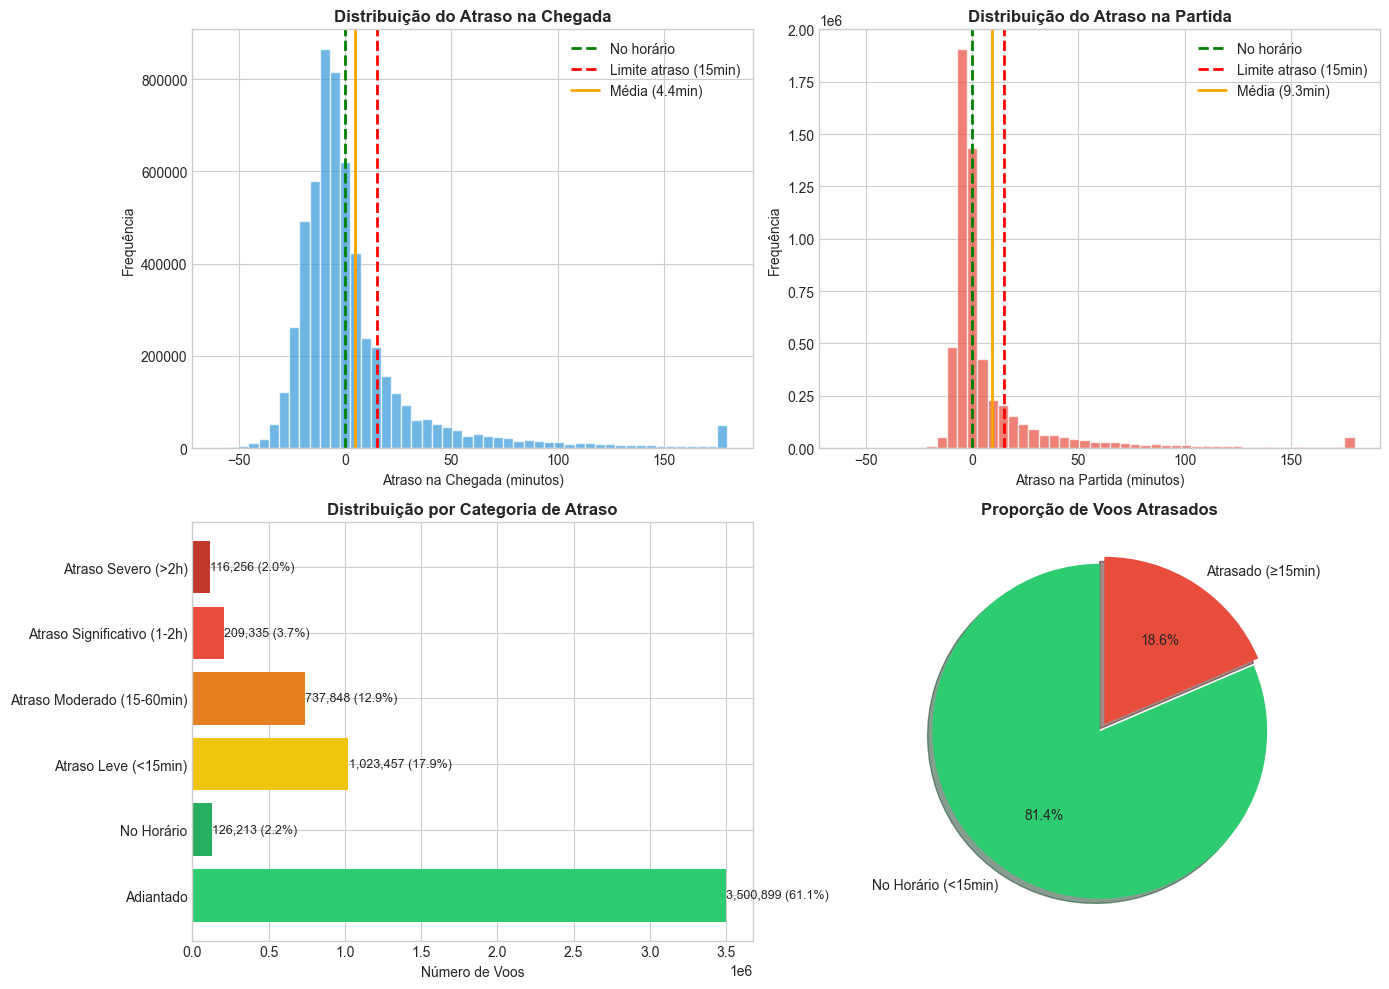


📊 ESTATÍSTICAS DOS ATRASOS:
   Atraso médio na chegada: 4.41 min
   Atraso mediano na chegada: -5.00 min
   Desvio padrão: 39.27 min
   Mínimo: -87 min (adiantado)
   Máximo: 1971 min


In [13]:
# 2.1 Variáveis Alvo (Atrasos)
print('='*60)
print('DISTRIBUIÇÃO DOS ATRASOS')
print('='*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 2.1.1 Histograma de ARRIVAL_DELAY (filtrado para visualização)
ax1 = axes[0, 0]
delay_filtered = df_valid['ARRIVAL_DELAY'].clip(-60, 180)  # Limitar para visualização
ax1.hist(delay_filtered, bins=50, color=COLORS[0], edgecolor='white', alpha=0.7)
ax1.axvline(x=0, color='green', linestyle='--', linewidth=2, label='No horário')
ax1.axvline(x=15, color='red', linestyle='--', linewidth=2, label='Limite atraso (15min)')
ax1.axvline(x=df_valid['ARRIVAL_DELAY'].mean(), color='orange', linestyle='-', linewidth=2, label=f'Média ({df_valid["ARRIVAL_DELAY"].mean():.1f}min)')
ax1.set_xlabel('Atraso na Chegada (minutos)')
ax1.set_ylabel('Frequência')
ax1.set_title('Distribuição do Atraso na Chegada', fontweight='bold')
ax1.legend()

# 2.1.2 Histograma de DEPARTURE_DELAY
ax2 = axes[0, 1]
delay_dep_filtered = df_valid['DEPARTURE_DELAY'].clip(-60, 180)
ax2.hist(delay_dep_filtered, bins=50, color=COLORS[1], edgecolor='white', alpha=0.7)
ax2.axvline(x=0, color='green', linestyle='--', linewidth=2, label='No horário')
ax2.axvline(x=15, color='red', linestyle='--', linewidth=2, label='Limite atraso (15min)')
ax2.axvline(x=df_valid['DEPARTURE_DELAY'].mean(), color='orange', linestyle='-', linewidth=2, label=f'Média ({df_valid["DEPARTURE_DELAY"].mean():.1f}min)')
ax2.set_xlabel('Atraso na Partida (minutos)')
ax2.set_ylabel('Frequência')
ax2.set_title('Distribuição do Atraso na Partida', fontweight='bold')
ax2.legend()

# 2.1.3 Distribuição por Categoria de Atraso
ax3 = axes[1, 0]
delay_cat_order = ['Adiantado', 'No Horário', 'Atraso Leve (<15min)', 'Atraso Moderado (15-60min)', 
                   'Atraso Significativo (1-2h)', 'Atraso Severo (>2h)']
delay_counts = df_valid['DELAY_CATEGORY'].value_counts().reindex(delay_cat_order)
colors_delay = ['#2ecc71', '#27ae60', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b']
bars = ax3.barh(delay_counts.index, delay_counts.values, color=colors_delay)
ax3.set_xlabel('Número de Voos')
ax3.set_title('Distribuição por Categoria de Atraso', fontweight='bold')
for bar, val in zip(bars, delay_counts.values):
    ax3.text(val + 1000, bar.get_y() + bar.get_height()/2, f'{val:,} ({val/len(df_valid)*100:.1f}%)', 
             va='center', fontsize=9)

# 2.1.4 Pie chart de voos atrasados vs não atrasados
ax4 = axes[1, 1]
delayed_counts = df_valid['IS_DELAYED'].value_counts()
labels = ['No Horário (<15min)', 'Atrasado (≥15min)']
colors_pie = ['#2ecc71', '#e74c3c']
ax4.pie(delayed_counts, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90,
        explode=(0, 0.05), shadow=True)
ax4.set_title('Proporção de Voos Atrasados', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/fig_01_distribuicao_atrasos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 ESTATÍSTICAS DOS ATRASOS:')
print(f'   Atraso médio na chegada: {df_valid["ARRIVAL_DELAY"].mean():.2f} min')
print(f'   Atraso mediano na chegada: {df_valid["ARRIVAL_DELAY"].median():.2f} min')
print(f'   Desvio padrão: {df_valid["ARRIVAL_DELAY"].std():.2f} min')
print(f'   Mínimo: {df_valid["ARRIVAL_DELAY"].min():.0f} min (adiantado)')
print(f'   Máximo: {df_valid["ARRIVAL_DELAY"].max():.0f} min')

In [14]:
# 2.2 Volume de Voos por Companhia Aérea
print('='*60)
print('VOLUME DE VOOS POR COMPANHIA AÉREA')
print('='*60)

# Contagem de voos por companhia
airline_counts = df['AIRLINE_NAME'].value_counts().reset_index()
airline_counts.columns = ['Companhia', 'Total_Voos']
airline_counts['Percentual'] = (airline_counts['Total_Voos'] / airline_counts['Total_Voos'].sum() * 100).round(2)

fig = px.bar(airline_counts, 
             x='Companhia', 
             y='Total_Voos',
             text='Total_Voos',
             color='Total_Voos',
             color_continuous_scale='Blues',
             title='Volume de Voos por Companhia Aérea')

fig.update_traces(texttemplate='%{text:,.0f}', textposition='outside')
fig.update_layout(xaxis_tickangle=-45, height=500, showlegend=False)
fig.show()

print('\n📊 TOP 5 COMPANHIAS AÉREAS POR VOLUME:')
display(airline_counts.head())

VOLUME DE VOOS POR COMPANHIA AÉREA



📊 TOP 5 COMPANHIAS AÉREAS POR VOLUME:


,Companhia,Total_Voos,Percentual
0,Southwest Airlines Co.,1261855,21.68
1,Delta Air Lines Inc.,875881,15.05
2,American Airlines Inc.,725984,12.48
3,Skywest Airlines Inc.,588353,10.11
4,Atlantic Southeast Airlines,571977,9.83


TOP 20 AEROPORTOS POR VOLUME DE VOOS


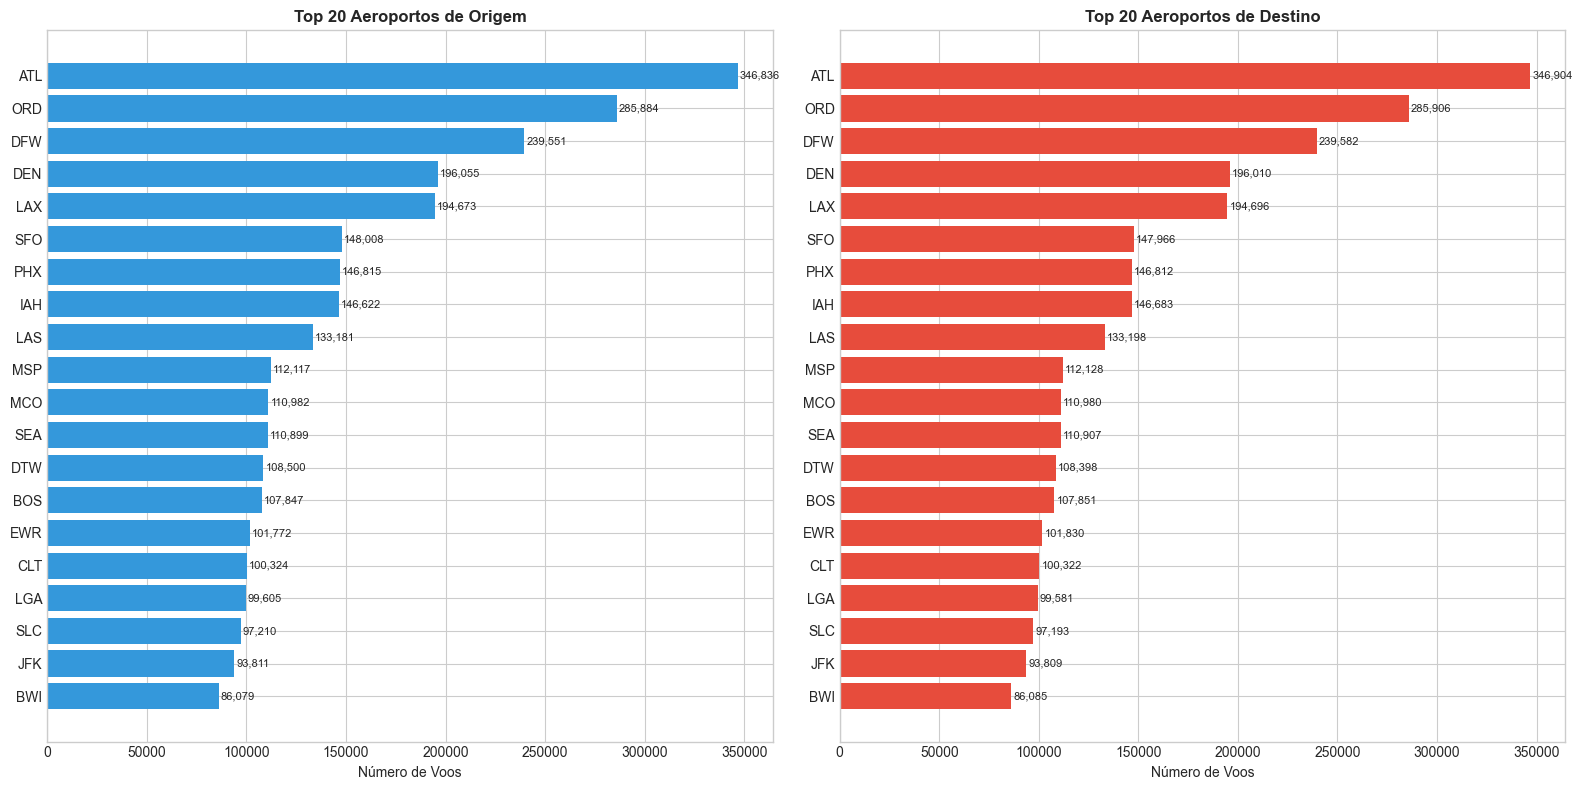


📊 TOP 5 AEROPORTOS DE ORIGEM:
   1. ATL (Hartsfield-Jackson Atlanta International...): 346,836 voos
   2. ORD (Chicago O'Hare International Airport...): 285,884 voos
   3. DFW (Dallas/Fort Worth International Airport...): 239,551 voos
   4. DEN (Denver International Airport...): 196,055 voos
   5. LAX (Los Angeles International Airport...): 194,673 voos


In [15]:
# 2.3 Volume de Voos por Aeroporto
print('='*60)
print('TOP 20 AEROPORTOS POR VOLUME DE VOOS')
print('='*60)

# Top 20 aeroportos de origem
origin_counts = df['ORIGIN_AIRPORT'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Aeroportos de origem
ax1 = axes[0]
bars1 = ax1.barh(origin_counts.index[::-1], origin_counts.values[::-1], color=COLORS[0])
ax1.set_xlabel('Número de Voos')
ax1.set_title('Top 20 Aeroportos de Origem', fontweight='bold')
for bar in bars1:
    ax1.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2, 
             f'{int(bar.get_width()):,}', va='center', fontsize=8)

# Aeroportos de destino
dest_counts = df['DESTINATION_AIRPORT'].value_counts().head(20)
ax2 = axes[1]
bars2 = ax2.barh(dest_counts.index[::-1], dest_counts.values[::-1], color=COLORS[1])
ax2.set_xlabel('Número de Voos')
ax2.set_title('Top 20 Aeroportos de Destino', fontweight='bold')
for bar in bars2:
    ax2.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2, 
             f'{int(bar.get_width()):,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/fig_02_top_aeroportos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 TOP 5 AEROPORTOS DE ORIGEM:')
for i, (airport, count) in enumerate(origin_counts.head().items(), 1):
    name = df_airports[df_airports['IATA_CODE'] == airport]['AIRPORT'].values
    name = name[0] if len(name) > 0 else 'N/A'
    print(f'   {i}. {airport} ({name[:40]}...): {count:,} voos')

DISTRIBUIÇÃO TEMPORAL DOS VOOS


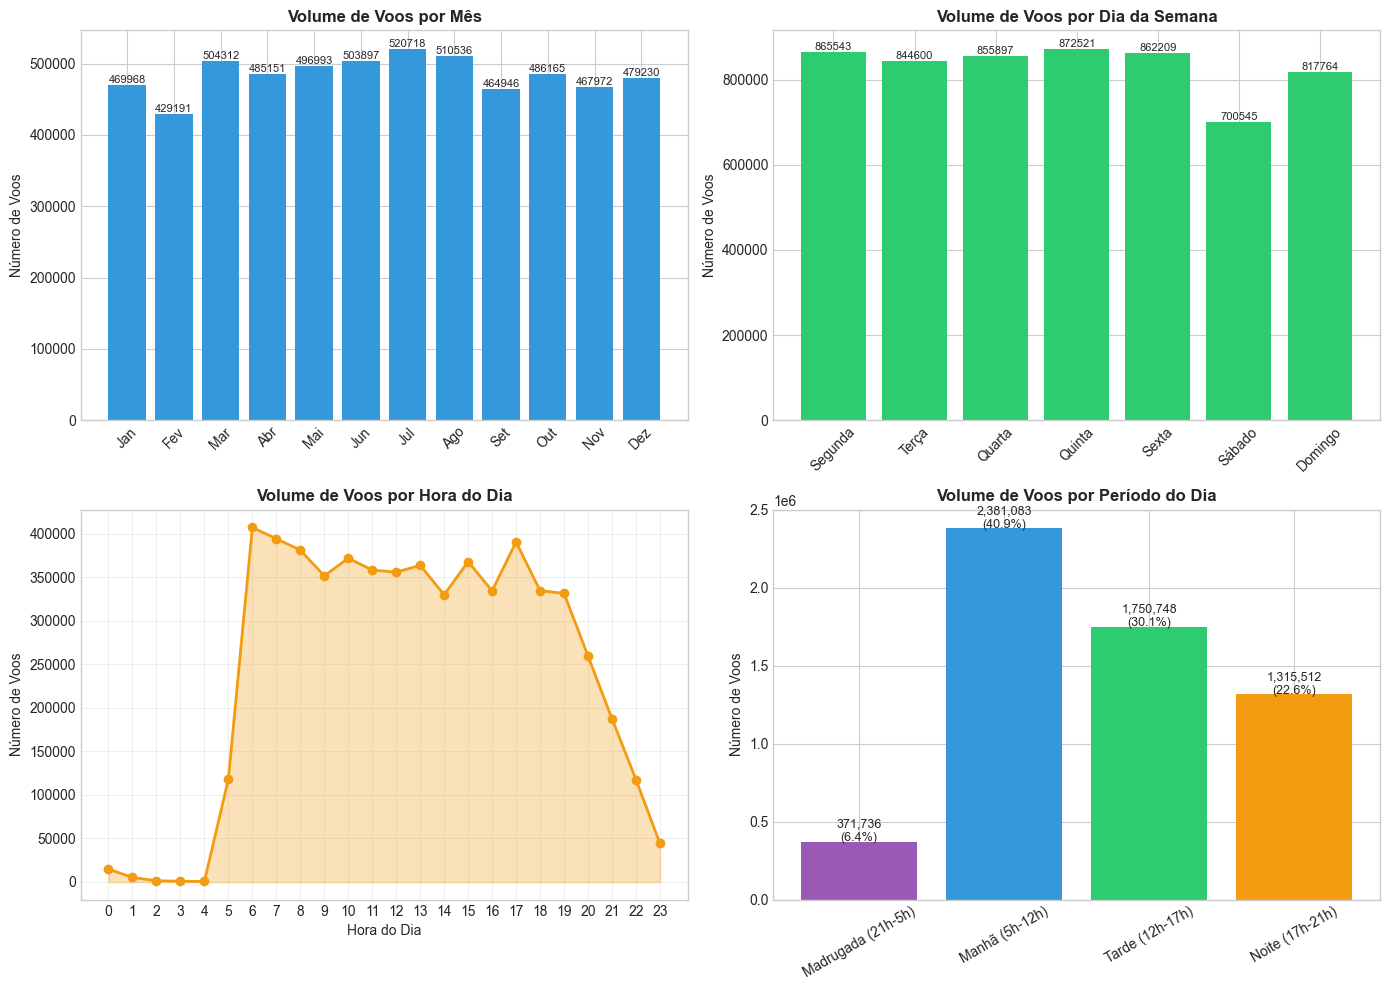

In [16]:
# 2.4 Análise Temporal dos Voos
print('='*60)
print('DISTRIBUIÇÃO TEMPORAL DOS VOOS')
print('='*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 2.4.1 Voos por Mês
ax1 = axes[0, 0]
month_order = ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho',
               'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']
month_counts = df['MONTH_NAME'].value_counts().reindex(month_order)
bars1 = ax1.bar(range(len(month_counts)), month_counts.values, color=COLORS[0])
ax1.set_xticks(range(len(month_counts)))
ax1.set_xticklabels([m[:3] for m in month_order], rotation=45)
ax1.set_ylabel('Número de Voos')
ax1.set_title('Volume de Voos por Mês', fontweight='bold')
ax1.bar_label(bars1, fmt='%.0f', fontsize=8)

# 2.4.2 Voos por Dia da Semana
ax2 = axes[0, 1]
day_order = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
day_counts = df['DAY_NAME'].value_counts().reindex(day_order)
bars2 = ax2.bar(day_order, day_counts.values, color=COLORS[2])
ax2.set_ylabel('Número de Voos')
ax2.set_title('Volume de Voos por Dia da Semana', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.bar_label(bars2, fmt='%.0f', fontsize=8)

# 2.4.3 Voos por Hora do Dia
ax3 = axes[1, 0]
hour_counts = df['HOUR'].value_counts().sort_index()
ax3.plot(hour_counts.index, hour_counts.values, marker='o', linewidth=2, color=COLORS[3])
ax3.fill_between(hour_counts.index, hour_counts.values, alpha=0.3, color=COLORS[3])
ax3.set_xlabel('Hora do Dia')
ax3.set_ylabel('Número de Voos')
ax3.set_title('Volume de Voos por Hora do Dia', fontweight='bold')
ax3.set_xticks(range(0, 24))
ax3.grid(True, alpha=0.3)

# 2.4.4 Voos por Período do Dia
ax4 = axes[1, 1]
period_order = ['Madrugada (21h-5h)', 'Manhã (5h-12h)', 'Tarde (12h-17h)', 'Noite (17h-21h)']
period_counts = df['PERIOD'].value_counts().reindex(period_order)
colors_period = [COLORS[4], COLORS[0], COLORS[2], COLORS[3]]
bars4 = ax4.bar(period_order, period_counts.values, color=colors_period)
ax4.set_ylabel('Número de Voos')
ax4.set_title('Volume de Voos por Período do Dia', fontweight='bold')
ax4.tick_params(axis='x', rotation=30)
for bar, val in zip(bars4, period_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
             f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/fig_03_distribuicao_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

DISTRIBUIÇÃO DA DISTÂNCIA DOS VOOS


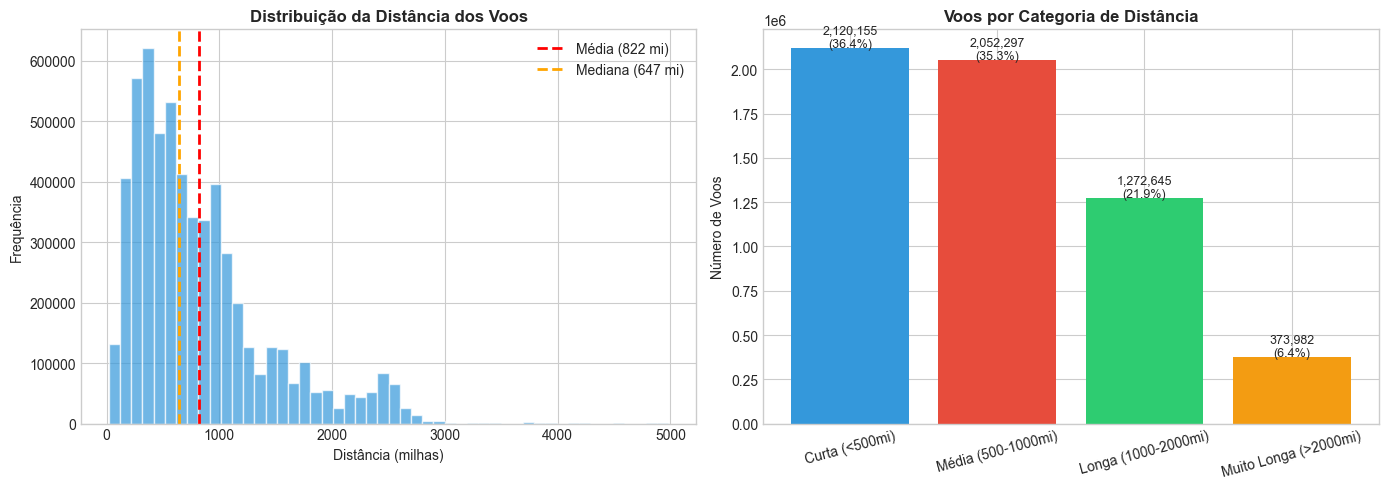


📊 ESTATÍSTICAS DE DISTÂNCIA:
   Distância média: 822 milhas
   Distância mediana: 647 milhas
   Menor distância: 21 milhas
   Maior distância: 4983 milhas


In [17]:
# 2.5 Distribuição de Distância dos Voos
print('='*60)
print('DISTRIBUIÇÃO DA DISTÂNCIA DOS VOOS')
print('='*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de distância
ax1 = axes[0]
ax1.hist(df['DISTANCE'], bins=50, color=COLORS[0], edgecolor='white', alpha=0.7)
ax1.axvline(x=df['DISTANCE'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Média ({df["DISTANCE"].mean():.0f} mi)')
ax1.axvline(x=df['DISTANCE'].median(), color='orange', linestyle='--', linewidth=2, 
            label=f'Mediana ({df["DISTANCE"].median():.0f} mi)')
ax1.set_xlabel('Distância (milhas)')
ax1.set_ylabel('Frequência')
ax1.set_title('Distribuição da Distância dos Voos', fontweight='bold')
ax1.legend()

# Box plot por categoria de distância
ax2 = axes[1]

# Criar categorias de distância
def categorize_distance(dist):
    if dist < 500:
        return 'Curta (<500mi)'
    elif dist < 1000:
        return 'Média (500-1000mi)'
    elif dist < 2000:
        return 'Longa (1000-2000mi)'
    else:
        return 'Muito Longa (>2000mi)'

df['DISTANCE_CATEGORY'] = df['DISTANCE'].apply(categorize_distance)
dist_cat_order = ['Curta (<500mi)', 'Média (500-1000mi)', 'Longa (1000-2000mi)', 'Muito Longa (>2000mi)']
dist_counts = df['DISTANCE_CATEGORY'].value_counts().reindex(dist_cat_order)
bars = ax2.bar(dist_cat_order, dist_counts.values, color=[COLORS[i] for i in range(4)])
ax2.set_ylabel('Número de Voos')
ax2.set_title('Voos por Categoria de Distância', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, dist_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
             f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/fig_04_distribuicao_distancia.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 ESTATÍSTICAS DE DISTÂNCIA:')
print(f'   Distância média: {df["DISTANCE"].mean():.0f} milhas')
print(f'   Distância mediana: {df["DISTANCE"].median():.0f} milhas')
print(f'   Menor distância: {df["DISTANCE"].min():.0f} milhas')
print(f'   Maior distância: {df["DISTANCE"].max():.0f} milhas')

---
# 3. Análise Bivariada

Análise da relação entre pares de variáveis, com foco nos atrasos.

ATRASO POR COMPANHIA AÉREA

📊 RANKING DE COMPANHIAS POR TAXA DE ATRASO:

📊 RANKING DE COMPANHIAS POR TAXA DE ATRASO:


,Atraso_Medio,Atraso_Mediano,Atraso_Std,Taxa_Atraso,Total_Voos
AIRLINE_NAME,,,,,
Spirit Air Lines,14.47,0.00,45.90,30.00,115375
Frontier Airlines Inc.,12.50,-1.00,51.56,26.00,90248
JetBlue Airways,6.68,-5.00,41.40,23.00,262772
American Eagle Airlines Inc.,6.46,-6.00,44.46,22.00,279607
United Air Lines Inc.,5.43,-6.00,44.08,21.00,509150
Atlantic Southeast Airlines,6.59,-4.00,40.68,20.00,556746
US Airways Inc.,3.71,-4.00,32.38,19.00,194648
Southwest Airlines Co.,4.37,-4.00,32.77,19.00,1245812
Virgin America,4.74,-3.00,35.62,19.00,61369


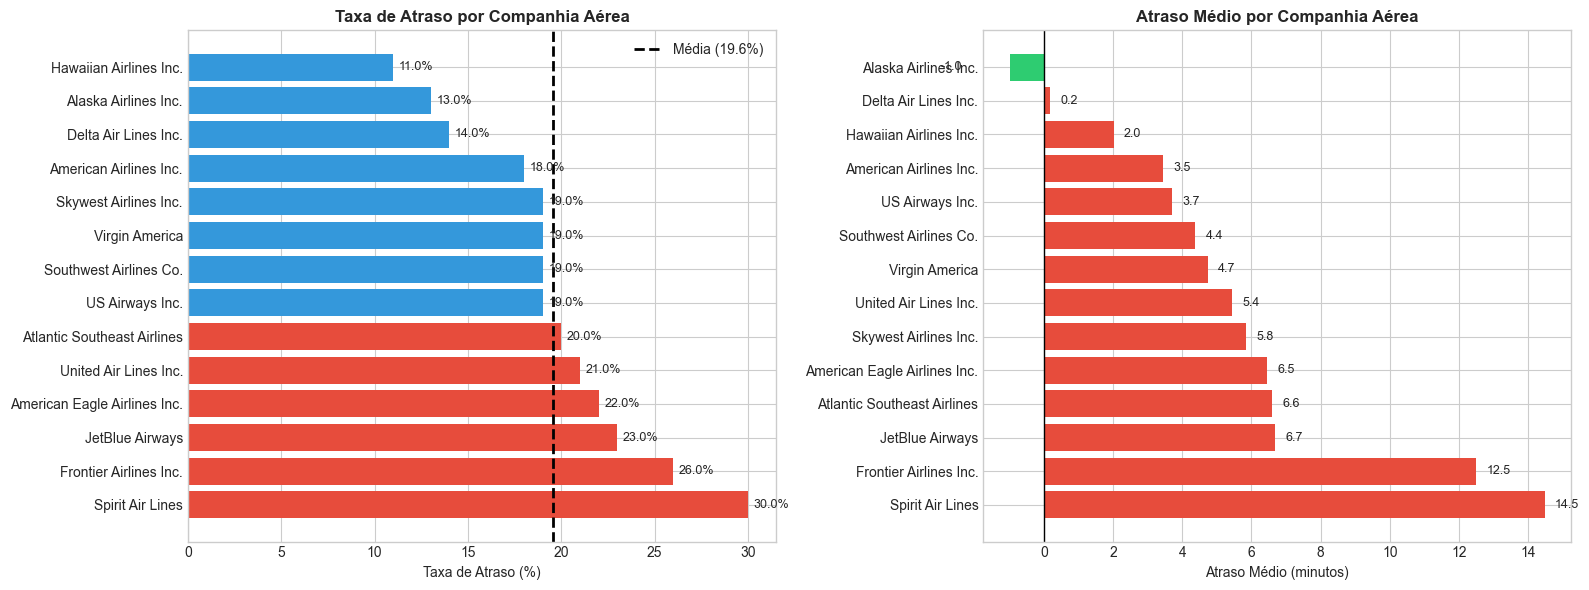

In [18]:
# 3.1 Atraso vs Companhia Aérea
print('='*60)
print('ATRASO POR COMPANHIA AÉREA')
print('='*60)

# Calcular métricas por companhia
airline_delay = df_valid.groupby('AIRLINE_NAME').agg({
    'ARRIVAL_DELAY': ['mean', 'median', 'std'],
    'IS_DELAYED': 'mean',
    'FLIGHT_NUMBER': 'count'
}).round(2)
airline_delay.columns = ['Atraso_Medio', 'Atraso_Mediano', 'Atraso_Std', 'Taxa_Atraso', 'Total_Voos']
airline_delay['Taxa_Atraso'] = (airline_delay['Taxa_Atraso'] * 100).round(2)
airline_delay = airline_delay.sort_values('Taxa_Atraso', ascending=False)

print('\n📊 RANKING DE COMPANHIAS POR TAXA DE ATRASO:')
display(airline_delay)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Taxa de atraso
ax1 = axes[0]
colors_airline = ['#e74c3c' if x > airline_delay['Taxa_Atraso'].mean() else '#3498db' 
                  for x in airline_delay['Taxa_Atraso']]
bars1 = ax1.barh(airline_delay.index, airline_delay['Taxa_Atraso'], color=colors_airline)
ax1.axvline(x=airline_delay['Taxa_Atraso'].mean(), color='black', linestyle='--', linewidth=2, 
            label=f'Média ({airline_delay["Taxa_Atraso"].mean():.1f}%)')
ax1.set_xlabel('Taxa de Atraso (%)')
ax1.set_title('Taxa de Atraso por Companhia Aérea', fontweight='bold')
ax1.legend()
for bar, val in zip(bars1, airline_delay['Taxa_Atraso']):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

# Atraso médio
ax2 = axes[1]
airline_delay_sorted = airline_delay.sort_values('Atraso_Medio', ascending=False)
colors_airline2 = ['#e74c3c' if x > 0 else '#2ecc71' for x in airline_delay_sorted['Atraso_Medio']]
bars2 = ax2.barh(airline_delay_sorted.index, airline_delay_sorted['Atraso_Medio'], color=colors_airline2)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Atraso Médio (minutos)')
ax2.set_title('Atraso Médio por Companhia Aérea', fontweight='bold')
for bar, val in zip(bars2, airline_delay_sorted['Atraso_Medio']):
    ax2.text(val + 0.3 if val > 0 else val - 2, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/fig_05_atraso_companhia.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# 3.2 Atraso vs Aeroportos
print('='*60)
print('TOP 20 AEROPORTOS COM MAIOR TAXA DE ATRASO (ORIGEM)')
print('='*60)

# Filtrar aeroportos com volume significativo (>1000 voos)
origin_stats = df_valid.groupby('ORIGIN_AIRPORT').agg({
    'ARRIVAL_DELAY': 'mean',
    'IS_DELAYED': 'mean',
    'FLIGHT_NUMBER': 'count'
}).round(2)
origin_stats.columns = ['Atraso_Medio', 'Taxa_Atraso', 'Total_Voos']
origin_stats['Taxa_Atraso'] = (origin_stats['Taxa_Atraso'] * 100).round(2)

# Filtrar aeroportos com mais de 5000 voos
origin_stats_filtered = origin_stats[origin_stats['Total_Voos'] >= 5000].sort_values('Taxa_Atraso', ascending=False)

fig = px.bar(origin_stats_filtered.head(20).reset_index(), 
             x='ORIGIN_AIRPORT', 
             y='Taxa_Atraso',
             color='Taxa_Atraso',
             color_continuous_scale='Reds',
             text='Taxa_Atraso',
             hover_data=['Atraso_Medio', 'Total_Voos'],
             title='Top 20 Aeroportos de Origem com Maior Taxa de Atraso (min. 5000 voos)')

fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(xaxis_tickangle=-45, height=500)
fig.show()

print('\n📊 TOP 10 AEROPORTOS MAIS PROBLEMÁTICOS (ORIGEM):')
top_10_origin = origin_stats_filtered.head(10)
for i, (airport, row) in enumerate(top_10_origin.iterrows(), 1):
    print(f'   {i:2}. {airport}: Taxa {row["Taxa_Atraso"]:.1f}% | Atraso médio {row["Atraso_Medio"]:.1f}min | {row["Total_Voos"]:,} voos')

TOP 20 AEROPORTOS COM MAIOR TAXA DE ATRASO (ORIGEM)



📊 TOP 10 AEROPORTOS MAIS PROBLEMÁTICOS (ORIGEM):
    1. HPN: Taxa 25.0% | Atraso médio 9.6min | 7,164.0 voos
    2. LGA: Taxa 24.0% | Atraso médio 5.6min | 95,074.0 voos
    3. ORD: Taxa 24.0% | Atraso médio 8.6min | 277,336.0 voos
    4. BWI: Taxa 23.0% | Atraso médio 7.2min | 84,546.0 voos
    5. XNA: Taxa 23.0% | Atraso médio 11.2min | 8,987.0 voos
    6. MIA: Taxa 23.0% | Atraso médio 7.0min | 68,558.0 voos
    7. HOU: Taxa 22.0% | Atraso médio 7.6min | 51,268.0 voos
    8. BTR: Taxa 22.0% | Atraso médio 11.2min | 7,003.0 voos
    9. DEN: Taxa 22.0% | Atraso médio 7.2min | 193,932.0 voos
   10. MDW: Taxa 22.0% | Atraso médio 6.0min | 78,927.0 voos


In [20]:
# 3.2.1 Top Aeroportos de Destino com Maior Atraso
print('='*60)
print('TOP 20 AEROPORTOS COM MAIOR TAXA DE ATRASO (DESTINO)')
print('='*60)

dest_stats = df_valid.groupby('DESTINATION_AIRPORT').agg({
    'ARRIVAL_DELAY': 'mean',
    'IS_DELAYED': 'mean',
    'FLIGHT_NUMBER': 'count'
}).round(2)
dest_stats.columns = ['Atraso_Medio', 'Taxa_Atraso', 'Total_Voos']
dest_stats['Taxa_Atraso'] = (dest_stats['Taxa_Atraso'] * 100).round(2)

dest_stats_filtered = dest_stats[dest_stats['Total_Voos'] >= 5000].sort_values('Taxa_Atraso', ascending=False)

fig = px.bar(dest_stats_filtered.head(20).reset_index(), 
             x='DESTINATION_AIRPORT', 
             y='Taxa_Atraso',
             color='Taxa_Atraso',
             color_continuous_scale='Reds',
             text='Taxa_Atraso',
             hover_data=['Atraso_Medio', 'Total_Voos'],
             title='Top 20 Aeroportos de Destino com Maior Taxa de Atraso (min. 5000 voos)')

fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(xaxis_tickangle=-45, height=500)
fig.show()

print('\n📊 TOP 10 AEROPORTOS MAIS PROBLEMÁTICOS (DESTINO):')
top_10_dest = dest_stats_filtered.head(10)
for i, (airport, row) in enumerate(top_10_dest.iterrows(), 1):
    print(f'   {i:2}. {airport}: Taxa {row["Taxa_Atraso"]:.1f}% | Atraso médio {row["Atraso_Medio"]:.1f}min | {row["Total_Voos"]:,} voos')

TOP 20 AEROPORTOS COM MAIOR TAXA DE ATRASO (DESTINO)



📊 TOP 10 AEROPORTOS MAIS PROBLEMÁTICOS (DESTINO):
    1. LGA: Taxa 26.0% | Atraso médio 10.4min | 95,163.0 voos
    2. COS: Taxa 24.0% | Atraso médio 10.2min | 6,771.0 voos
    3. TYS: Taxa 24.0% | Atraso médio 10.6min | 6,774.0 voos
    4. HPN: Taxa 24.0% | Atraso médio 9.0min | 7,207.0 voos
    5. LAX: Taxa 23.0% | Atraso médio 6.1min | 192,437.0 voos
    6. SJU: Taxa 23.0% | Atraso médio 6.9min | 24,487.0 voos
    7. FSD: Taxa 23.0% | Atraso médio 9.0min | 5,198.0 voos
    8. PBI: Taxa 23.0% | Atraso médio 6.9min | 22,245.0 voos
    9. XNA: Taxa 23.0% | Atraso médio 8.8min | 9,019.0 voos
   10. SGF: Taxa 23.0% | Atraso médio 8.7min | 6,079.0 voos


ATRASO VS DISTÂNCIA DO VOO


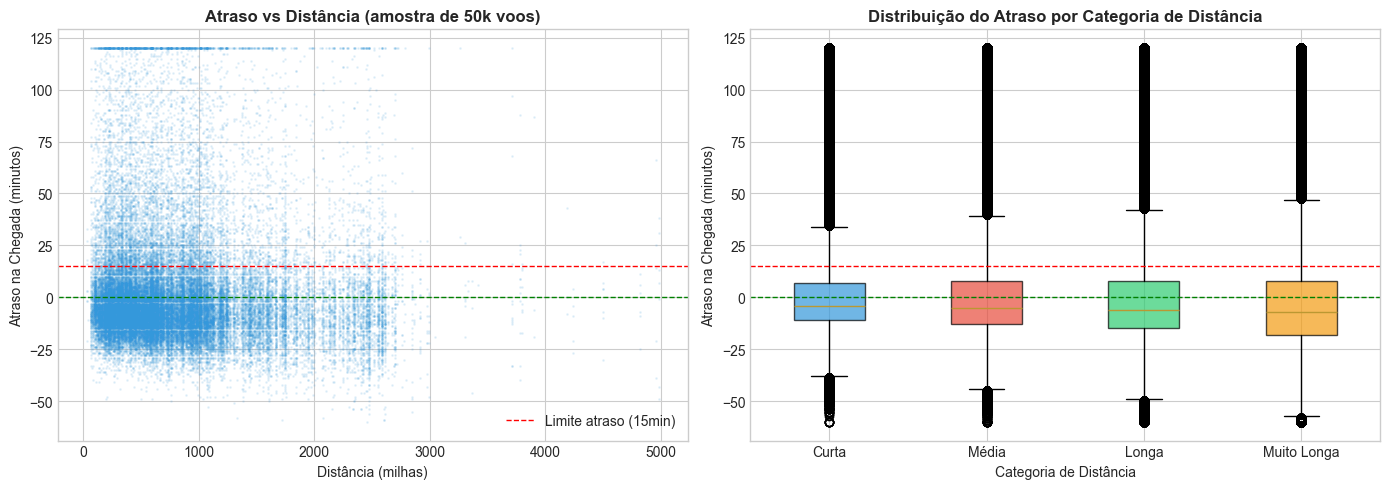


📊 ESTATÍSTICAS DE ATRASO POR CATEGORIA DE DISTÂNCIA:


,Atraso_Medio,Atraso_Mediano,Taxa_Atraso
DISTANCE_CATEGORY,,,
Curta (<500mi),5.16,-4.00,18.00
Média (500-1000mi),4.64,-5.00,19.00
Longa (1000-2000mi),3.77,-6.00,19.00
Muito Longa (>2000mi),1.07,-7.00,18.00


In [21]:
# 3.3 Atraso vs Distância do Voo
print('='*60)
print('ATRASO VS DISTÂNCIA DO VOO')
print('='*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot com amostra (para performance)
ax1 = axes[0]
sample = df_valid.sample(n=50000, random_state=42)
ax1.scatter(sample['DISTANCE'], sample['ARRIVAL_DELAY'].clip(-60, 120), 
            alpha=0.1, s=1, color=COLORS[0])
ax1.axhline(y=0, color='green', linestyle='--', linewidth=1)
ax1.axhline(y=15, color='red', linestyle='--', linewidth=1, label='Limite atraso (15min)')
ax1.set_xlabel('Distância (milhas)')
ax1.set_ylabel('Atraso na Chegada (minutos)')
ax1.set_title('Atraso vs Distância (amostra de 50k voos)', fontweight='bold')
ax1.legend()

# Box plot por categoria de distância
ax2 = axes[1]
dist_cat_order = ['Curta (<500mi)', 'Média (500-1000mi)', 'Longa (1000-2000mi)', 'Muito Longa (>2000mi)']
df_valid_dist = df_valid.copy()
df_valid_dist['DISTANCE_CATEGORY'] = df_valid_dist['DISTANCE'].apply(categorize_distance)

boxplot_data = [df_valid_dist[df_valid_dist['DISTANCE_CATEGORY'] == cat]['ARRIVAL_DELAY'].clip(-60, 120).dropna() 
                for cat in dist_cat_order]
bp = ax2.boxplot(boxplot_data, labels=['Curta', 'Média', 'Longa', 'Muito Longa'], patch_artist=True)
for patch, color in zip(bp['boxes'], COLORS[:4]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.axhline(y=0, color='green', linestyle='--', linewidth=1)
ax2.axhline(y=15, color='red', linestyle='--', linewidth=1)
ax2.set_xlabel('Categoria de Distância')
ax2.set_ylabel('Atraso na Chegada (minutos)')
ax2.set_title('Distribuição do Atraso por Categoria de Distância', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/fig_06_atraso_distancia.png', dpi=150, bbox_inches='tight')
plt.show()

# Estatísticas por categoria
print('\n📊 ESTATÍSTICAS DE ATRASO POR CATEGORIA DE DISTÂNCIA:')
dist_delay_stats = df_valid_dist.groupby('DISTANCE_CATEGORY').agg({
    'ARRIVAL_DELAY': ['mean', 'median'],
    'IS_DELAYED': 'mean'
}).round(2)
dist_delay_stats.columns = ['Atraso_Medio', 'Atraso_Mediano', 'Taxa_Atraso']
dist_delay_stats['Taxa_Atraso'] = (dist_delay_stats['Taxa_Atraso'] * 100).round(2)
dist_delay_stats = dist_delay_stats.reindex(dist_cat_order)
display(dist_delay_stats)

MATRIZ DE CORRELAÇÃO


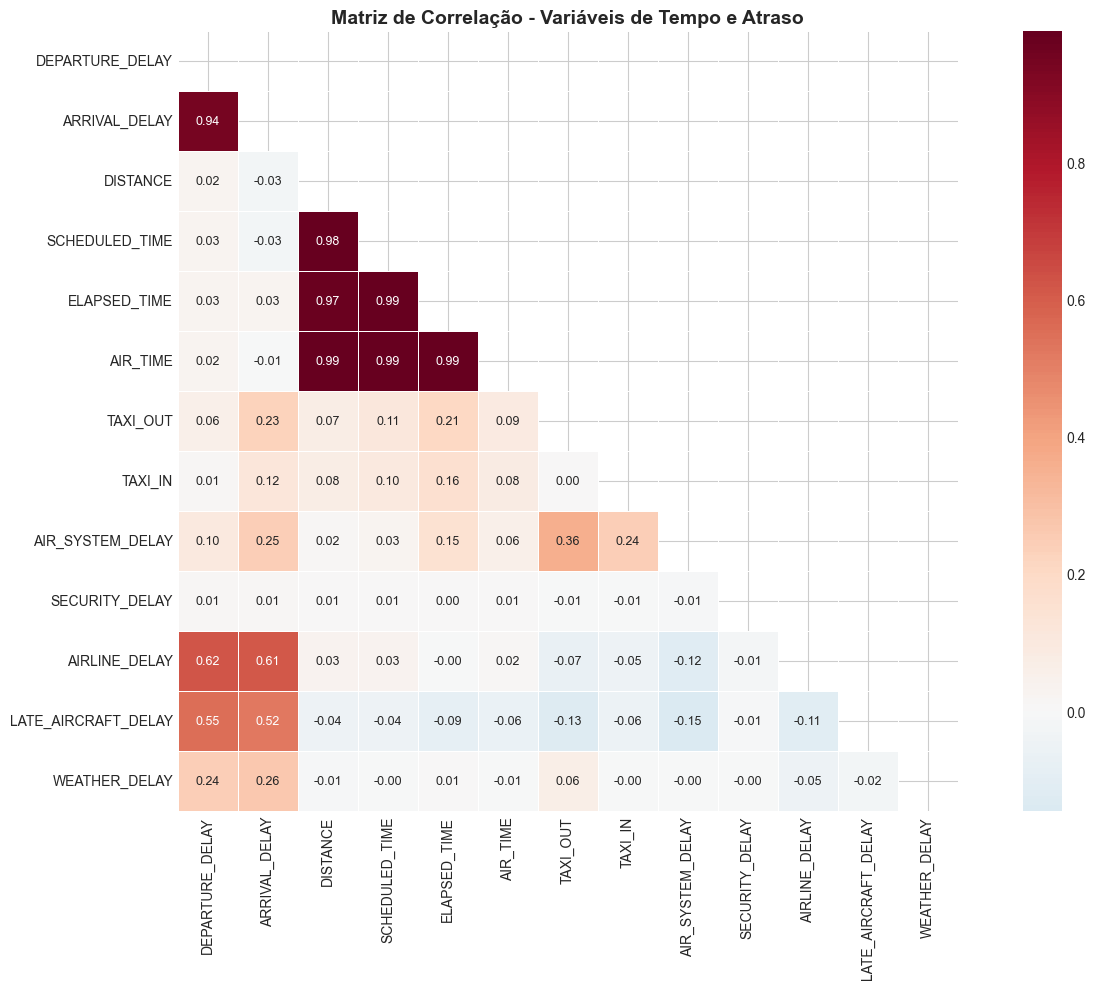


📊 CORRELAÇÕES MAIS FORTES COM ARRIVAL_DELAY:
   DEPARTURE_DELAY: 0.945
   AIRLINE_DELAY: 0.609
   LATE_AIRCRAFT_DELAY: 0.522
   WEATHER_DELAY: 0.265
   AIR_SYSTEM_DELAY: 0.247
   TAXI_OUT: 0.227


In [22]:
# 3.4 Matriz de Correlação
print('='*60)
print('MATRIZ DE CORRELAÇÃO')
print('='*60)

# Selecionar variáveis numéricas relevantes
corr_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE', 'SCHEDULED_TIME', 
             'ELAPSED_TIME', 'AIR_TIME', 'TAXI_OUT', 'TAXI_IN', 
             'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 
             'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

corr_matrix = df_valid[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Matriz de Correlação - Variáveis de Tempo e Atraso', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_07_matriz_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 CORRELAÇÕES MAIS FORTES COM ARRIVAL_DELAY:')
arrival_corr = corr_matrix['ARRIVAL_DELAY'].drop('ARRIVAL_DELAY').sort_values(key=abs, ascending=False)
for var, corr in arrival_corr.head(6).items():
    print(f'   {var}: {corr:.3f}')

---
# 4. Análise Multivariada

Análise de padrões envolvendo múltiplas variáveis simultaneamente.

HEATMAP: ATRASO POR DIA DA SEMANA E HORA


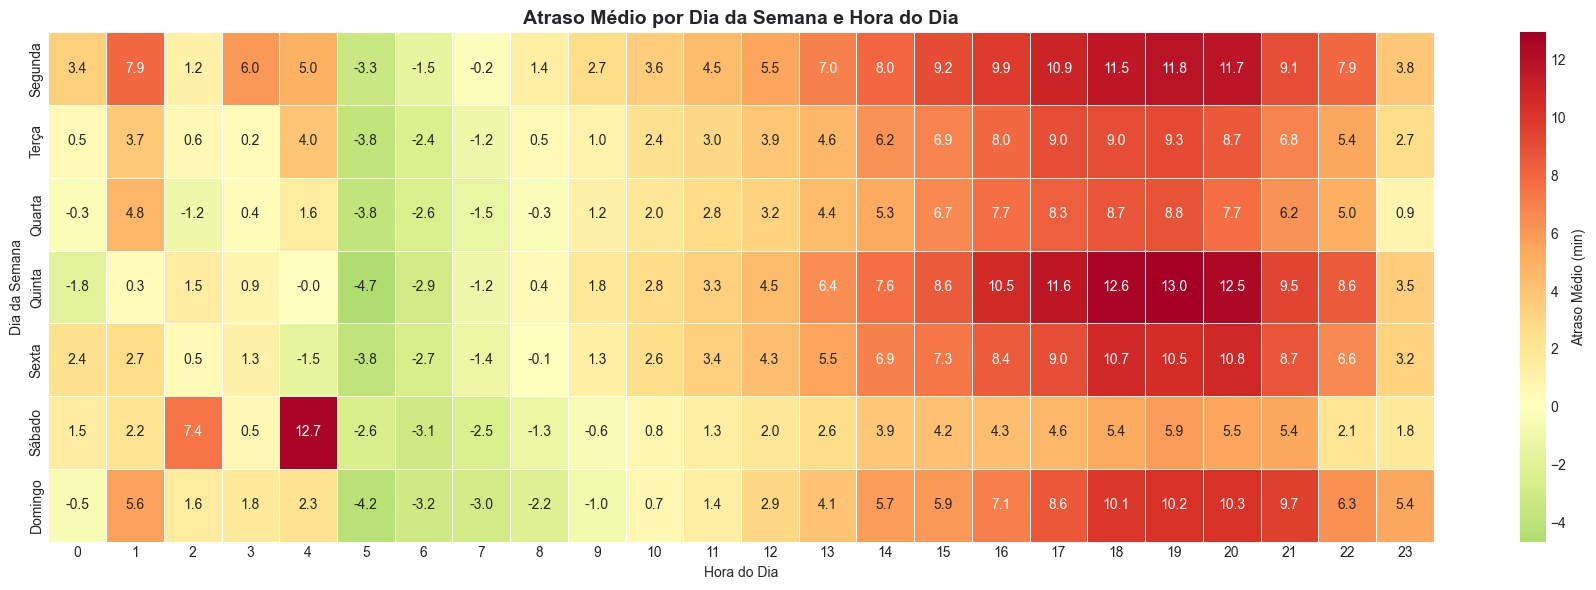


📊 INSIGHTS:
   Maior atraso médio: 13.0min (Quinta às 19h)
   Menor atraso médio: -4.7min (Quinta às 5h)


In [23]:
# 4.1 Heatmap: Atraso por Dia da Semana e Hora
print('='*60)
print('HEATMAP: ATRASO POR DIA DA SEMANA E HORA')
print('='*60)

# Criar pivot table
heatmap_data = df_valid.pivot_table(
    values='ARRIVAL_DELAY', 
    index='DAY_NAME', 
    columns='HOUR', 
    aggfunc='mean'
)

# Reordenar dias da semana
day_order = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
heatmap_data = heatmap_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Atraso Médio (min)'})
ax.set_xlabel('Hora do Dia')
ax.set_ylabel('Dia da Semana')
ax.set_title('Atraso Médio por Dia da Semana e Hora do Dia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_08_heatmap_dia_hora.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 INSIGHTS:')
max_delay_idx = np.unravel_index(heatmap_data.values.argmax(), heatmap_data.shape)
min_delay_idx = np.unravel_index(heatmap_data.values.argmin(), heatmap_data.shape)
print(f'   Maior atraso médio: {heatmap_data.iloc[max_delay_idx[0], max_delay_idx[1]]:.1f}min ({day_order[max_delay_idx[0]]} às {heatmap_data.columns[max_delay_idx[1]]}h)')
print(f'   Menor atraso médio: {heatmap_data.iloc[min_delay_idx[0], min_delay_idx[1]]:.1f}min ({day_order[min_delay_idx[0]]} às {heatmap_data.columns[min_delay_idx[1]]}h)')

HEATMAP: ATRASO POR MÊS E COMPANHIA AÉREA


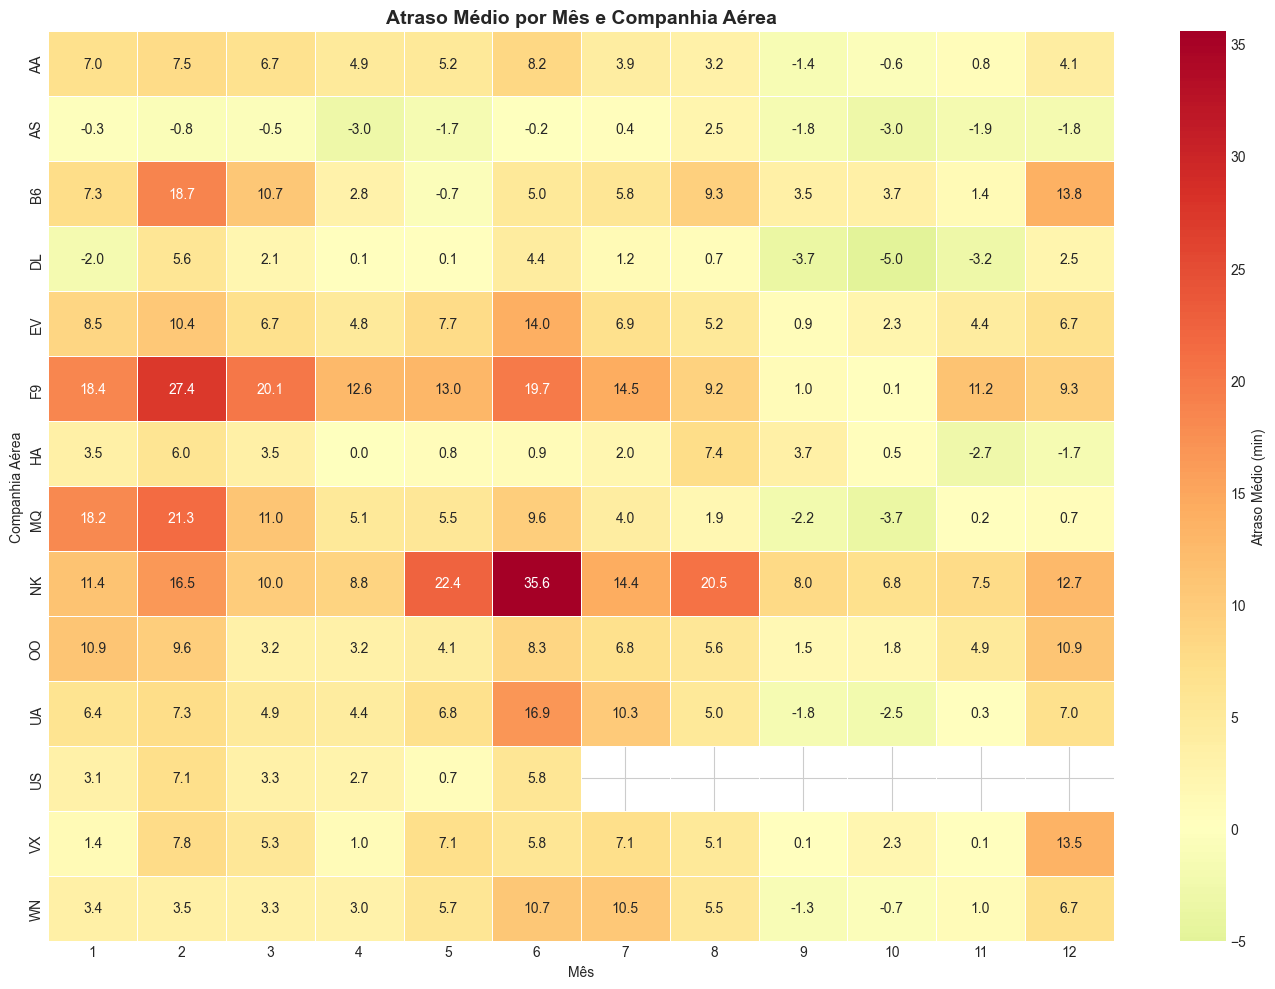


📊 ANÁLISE SAZONAL POR COMPANHIA:
   AA: Pior mês = Junho (8.2min) | Melhor mês = Setembro (-1.4min)
   AS: Pior mês = Agosto (2.5min) | Melhor mês = Abril (-3.0min)
   B6: Pior mês = Fevereiro (18.7min) | Melhor mês = Maio (-0.7min)
   DL: Pior mês = Fevereiro (5.6min) | Melhor mês = Outubro (-5.0min)
   EV: Pior mês = Junho (14.0min) | Melhor mês = Setembro (0.9min)
   F9: Pior mês = Fevereiro (27.4min) | Melhor mês = Outubro (0.1min)
   HA: Pior mês = Agosto (7.4min) | Melhor mês = Novembro (-2.7min)
   MQ: Pior mês = Fevereiro (21.3min) | Melhor mês = Outubro (-3.7min)
   NK: Pior mês = Junho (35.6min) | Melhor mês = Outubro (6.8min)
   OO: Pior mês = Dezembro (10.9min) | Melhor mês = Setembro (1.5min)
   UA: Pior mês = Junho (16.9min) | Melhor mês = Outubro (-2.5min)
   US: Pior mês = Fevereiro (7.1min) | Melhor mês = Maio (0.7min)
   VX: Pior mês = Dezembro (13.5min) | Melhor mês = Setembro (0.1min)
   WN: Pior mês = Junho (10.7min) | Melhor mês = Setembro (-1.3min)


In [24]:
# 4.2 Heatmap: Atraso por Mês e Companhia Aérea
print('='*60)
print('HEATMAP: ATRASO POR MÊS E COMPANHIA AÉREA')
print('='*60)

# Criar pivot table
heatmap_airline = df_valid.pivot_table(
    values='ARRIVAL_DELAY', 
    index='AIRLINE', 
    columns='MONTH', 
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(heatmap_airline, annot=True, fmt='.1f', cmap='RdYlGn_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Atraso Médio (min)'})
ax.set_xlabel('Mês')
ax.set_ylabel('Companhia Aérea')
ax.set_title('Atraso Médio por Mês e Companhia Aérea', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_09_heatmap_mes_airline.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 ANÁLISE SAZONAL POR COMPANHIA:')
for airline in heatmap_airline.index:
    worst_month = heatmap_airline.loc[airline].idxmax()
    best_month = heatmap_airline.loc[airline].idxmin()
    print(f'   {airline}: Pior mês = {month_names[worst_month]} ({heatmap_airline.loc[airline, worst_month]:.1f}min) | Melhor mês = {month_names[best_month]} ({heatmap_airline.loc[airline, best_month]:.1f}min)')

In [25]:
# 4.3 Análise de Rotas Mais Problemáticas
print('='*60)
print('TOP 20 ROTAS MAIS PROBLEMÁTICAS')
print('='*60)

# Calcular métricas por rota
route_stats = df_valid.groupby('ROUTE').agg({
    'ARRIVAL_DELAY': ['mean', 'median'],
    'IS_DELAYED': 'mean',
    'FLIGHT_NUMBER': 'count'
}).round(2)
route_stats.columns = ['Atraso_Medio', 'Atraso_Mediano', 'Taxa_Atraso', 'Total_Voos']
route_stats['Taxa_Atraso'] = (route_stats['Taxa_Atraso'] * 100).round(2)

# Filtrar rotas com mais de 500 voos
route_stats_filtered = route_stats[route_stats['Total_Voos'] >= 500].sort_values('Taxa_Atraso', ascending=False)

# Top 20 piores rotas
top_20_routes = route_stats_filtered.head(20).reset_index()

fig = px.bar(top_20_routes, 
             x='ROUTE', 
             y='Taxa_Atraso',
             color='Atraso_Medio',
             color_continuous_scale='Reds',
             text='Taxa_Atraso',
             hover_data=['Atraso_Medio', 'Total_Voos'],
             title='Top 20 Rotas com Maior Taxa de Atraso (min. 500 voos)')

fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(xaxis_tickangle=-45, height=600)
fig.show()

print('\n📊 TOP 10 ROTAS MAIS PROBLEMÁTICAS:')
for i, row in top_20_routes.head(10).iterrows():
    print(f'   {i+1:2}. {row["ROUTE"]}: Taxa {row["Taxa_Atraso"]:.1f}% | Atraso médio {row["Atraso_Medio"]:.1f}min | {row["Total_Voos"]:,} voos')

TOP 20 ROTAS MAIS PROBLEMÁTICAS



📊 TOP 10 ROTAS MAIS PROBLEMÁTICAS:
    1. DFW → HNL: Taxa 40.0% | Atraso médio 28.6min | 695 voos
    2. ORD → ASE: Taxa 39.0% | Atraso médio 22.3min | 597 voos
    3. LGA → MYR: Taxa 38.0% | Atraso médio 17.8min | 619 voos
    4. ORD → BOI: Taxa 37.0% | Atraso médio 18.5min | 527 voos
    5. DCA → JFK: Taxa 36.0% | Atraso médio 21.0min | 882 voos
    6. ORD → COS: Taxa 35.0% | Atraso médio 18.6min | 911 voos
    7. LGA → CMH: Taxa 34.0% | Atraso médio 12.4min | 1,316 voos
    8. IAH → LAX: Taxa 33.0% | Atraso médio 16.7min | 4,393 voos
    9. RDU → LGA: Taxa 33.0% | Atraso médio 17.2min | 1,681 voos
   10. RIC → LGA: Taxa 33.0% | Atraso médio 17.9min | 1,287 voos


In [26]:
# 4.4 Evolução Temporal dos Atrasos
print('='*60)
print('EVOLUÇÃO TEMPORAL DOS ATRASOS')
print('='*60)

# Atraso médio por dia
daily_delay = df_valid.groupby('DATE').agg({
    'ARRIVAL_DELAY': 'mean',
    'IS_DELAYED': 'mean',
    'FLIGHT_NUMBER': 'count'
}).reset_index()
daily_delay.columns = ['Date', 'Atraso_Medio', 'Taxa_Atraso', 'Total_Voos']
daily_delay['Taxa_Atraso'] = daily_delay['Taxa_Atraso'] * 100

# Média móvel de 7 dias
daily_delay['Atraso_MM7'] = daily_delay['Atraso_Medio'].rolling(window=7, center=True).mean()
daily_delay['Taxa_MM7'] = daily_delay['Taxa_Atraso'].rolling(window=7, center=True).mean()

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    subplot_titles=('Atraso Médio Diário', 'Taxa de Atraso Diária'),
                    vertical_spacing=0.1)

# Atraso médio
fig.add_trace(go.Scatter(x=daily_delay['Date'], y=daily_delay['Atraso_Medio'],
                         mode='lines', name='Atraso Diário', opacity=0.3, line=dict(color='blue')),
              row=1, col=1)
fig.add_trace(go.Scatter(x=daily_delay['Date'], y=daily_delay['Atraso_MM7'],
                         mode='lines', name='Média Móvel 7 dias', line=dict(color='red', width=2)),
              row=1, col=1)

# Taxa de atraso
fig.add_trace(go.Scatter(x=daily_delay['Date'], y=daily_delay['Taxa_Atraso'],
                         mode='lines', name='Taxa Diária', opacity=0.3, line=dict(color='green')),
              row=2, col=1)
fig.add_trace(go.Scatter(x=daily_delay['Date'], y=daily_delay['Taxa_MM7'],
                         mode='lines', name='Média Móvel 7 dias', line=dict(color='orange', width=2)),
              row=2, col=1)

fig.update_layout(height=700, title_text='Evolução Temporal dos Atrasos ao Longo do Ano', showlegend=True)
fig.update_yaxes(title_text='Atraso (min)', row=1, col=1)
fig.update_yaxes(title_text='Taxa (%)', row=2, col=1)
fig.show()

print('\n📊 PICOS DE ATRASO:')
top_delay_days = daily_delay.nlargest(5, 'Atraso_Medio')[['Date', 'Atraso_Medio', 'Taxa_Atraso', 'Total_Voos']]
print('\n   Top 5 dias com maior atraso médio:')
for _, row in top_delay_days.iterrows():
    print(f'   {row["Date"].strftime("%d/%m/%Y")}: {row["Atraso_Medio"]:.1f}min (Taxa: {row["Taxa_Atraso"]:.1f}%, Voos: {row["Total_Voos"]:,})')

EVOLUÇÃO TEMPORAL DOS ATRASOS



📊 PICOS DE ATRASO:

   Top 5 dias com maior atraso médio:
   04/01/2015: 32.0min (Taxa: 49.2%, Voos: 15,919)
   27/12/2015: 28.2min (Taxa: 39.4%, Voos: 15,351)
   29/12/2015: 26.3min (Taxa: 39.8%, Voos: 15,514)
   30/12/2015: 26.2min (Taxa: 43.5%, Voos: 15,979)
   01/03/2015: 25.9min (Taxa: 40.9%, Voos: 13,657)


In [43]:
# 4.5 Análise de Padrões Combinados (Interativo)
print('='*60)
print('ANÁLISE INTERATIVA: ATRASO POR COMPANHIA, MÊS E PERÍODO')
print('='*60)

# Agregar dados por companhia, mês e período
pattern_data = df_valid.groupby(['AIRLINE', 'MONTH_NAME', 'PERIOD']).agg({
    'ARRIVAL_DELAY': 'mean',
    'IS_DELAYED': 'mean',
    'FLIGHT_NUMBER': 'count'
}).reset_index()
pattern_data.columns = ['Companhia', 'Mes', 'Periodo', 'Atraso_Medio', 'Taxa_Atraso', 'Total_Voos']
pattern_data = pattern_data[pattern_data['Atraso_Medio'] >= 15]
pattern_data['Taxa_Atraso'] = (pattern_data['Taxa_Atraso'] * 100).round(2)

# Sunburst chart
fig = px.sunburst(pattern_data, 
                  path=['Companhia', 'Periodo'], 
                  values='Total_Voos',
                  color='Atraso_Medio',
                  color_continuous_scale='RdYlGn_r',
                  title='Distribuição de Voos por Companhia e Período (cor = Atraso Médio)')
fig.update_layout(height=600)
fig.show()

ANÁLISE INTERATIVA: ATRASO POR COMPANHIA, MÊS E PERÍODO


In [42]:
pattern_data

,Companhia,Mes,Periodo,Atraso_Medio,Taxa_Atraso,Total_Voos
0,AA,Abril,Madrugada (21h-5h),5.28,21.52,2686
1,AA,Abril,Manhã (5h-12h),1.24,14.60,18645
2,AA,Abril,Noite (17h-21h),10.76,27.82,9887
3,AA,Abril,Tarde (12h-17h),5.72,20.33,13198
4,AA,Agosto,Madrugada (21h-5h),6.23,23.18,5661
...,...,...,...,...,...,...
643,WN,Outubro,Tarde (12h-17h),1.39,14.50,31728
644,WN,Setembro,Madrugada (21h-5h),2.01,16.16,4121
645,WN,Setembro,Manhã (5h-12h),-5.78,6.20,41864
646,WN,Setembro,Noite (17h-21h),3.54,18.42,23690


In [40]:
# 4.6 Treemap: Atrasos por Estado de Origem
print('='*60)
print('TREEMAP: ATRASOS POR ESTADO')
print('='*60)

# Agregar por estado
state_stats = df_valid.groupby('ORIGIN_STATE').agg({
    'ARRIVAL_DELAY': 'mean',
    'IS_DELAYED': 'mean',
    'FLIGHT_NUMBER': 'count'
}).reset_index()
state_stats.columns = ['Estado', 'Atraso_Medio', 'Taxa_Atraso', 'Total_Voos']
state_stats['Taxa_Atraso'] = (state_stats['Taxa_Atraso'] * 100).round(2)
#state_stats = state_stats[state_stats['Taxa_Atraso'] >= 23]
state_stats = state_stats.dropna()

fig = px.treemap(state_stats, 
                 path=['Estado'], 
                 values='Total_Voos',
                 color='Taxa_Atraso',
                 color_continuous_scale='RdYlGn_r',
                 title='Volume de Voos por Estado (cor = Taxa de Atraso %)',
                 hover_data=['Atraso_Medio', 'Taxa_Atraso'])
fig.update_layout(height=600)
fig.show()

print('\n📊 TOP 10 ESTADOS COM MAIOR TAXA DE ATRASO (min. 10000 voos):')
state_stats_filtered = state_stats[state_stats['Total_Voos'] >= 10000].sort_values('Taxa_Atraso', ascending=False)
for i, row in state_stats_filtered.head(10).iterrows():
    print(f'   {row["Estado"]}: Taxa {row["Taxa_Atraso"]:.1f}% | Atraso médio {row["Atraso_Medio"]:.1f}min | {row["Total_Voos"]:,} voos')

TREEMAP: ATRASOS POR ESTADO



📊 TOP 10 ESTADOS COM MAIOR TAXA DE ATRASO (min. 10000 voos):
   IL: Taxa 23.4% | Atraso médio 8.0min | 370,549 voos
   MD: Taxa 22.5% | Atraso médio 7.2min | 84,546 voos
   CO: Taxa 22.1% | Atraso médio 7.2min | 212,735 voos
   NY: Taxa 21.7% | Atraso médio 4.1min | 238,531 voos
   NJ: Taxa 21.5% | Atraso médio 4.8min | 104,973 voos
   TX: Taxa 20.5% | Atraso médio 6.7min | 618,298 voos
   NV: Taxa 20.3% | Atraso médio 5.9min | 145,640 voos
   MA: Taxa 20.3% | Atraso médio 4.3min | 106,603 voos
   AR: Taxa 20.3% | Atraso médio 8.1min | 21,973 voos
   IA: Taxa 20.0% | Atraso médio 7.1min | 16,781 voos


In [41]:
state_stats

,Estado,Atraso_Medio,Taxa_Atraso,Total_Voos
0,AK,1.45,14.68,32905
1,AL,5.40,17.90,26051
2,AR,8.14,20.29,21973
3,AS,21.50,28.97,107
4,AZ,4.20,18.34,164340
5,CA,5.12,19.20,639837
6,CO,7.23,22.12,212735
7,CT,0.76,15.78,18437
8,DE,24.06,38.95,95
9,FL,5.57,19.55,410990


---
# 5. Análise de Motivos (Drill-down)

Análise detalhada dos tipos de atraso e seus padrões.

COMPOSIÇÃO DOS TIPOS DE ATRASO


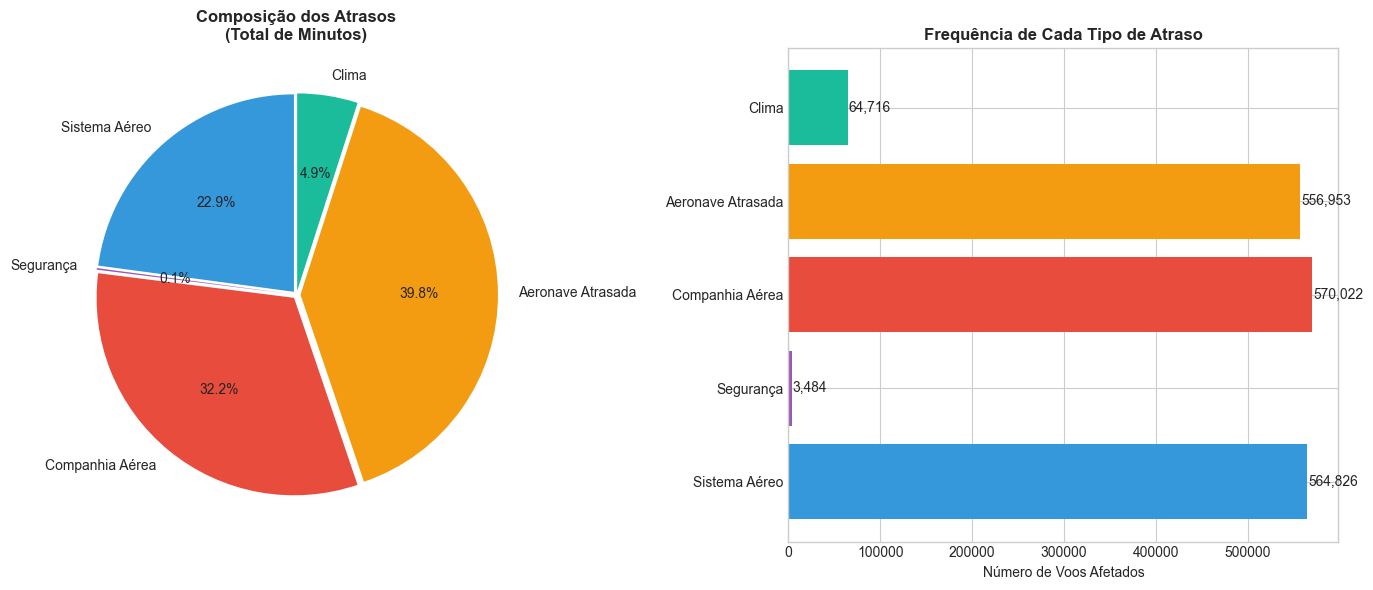


📊 ESTATÍSTICAS POR TIPO DE ATRASO:
   Sistema Aéreo:
      Total: 14,335,762 minutos | Voos afetados: 564,826 | Média quando ocorre: 25.4min
   Segurança:
      Total: 80,985 minutos | Voos afetados: 3,484 | Média quando ocorre: 23.2min
   Sistema Aéreo:
      Total: 14,335,762 minutos | Voos afetados: 564,826 | Média quando ocorre: 25.4min
   Segurança:
      Total: 80,985 minutos | Voos afetados: 3,484 | Média quando ocorre: 23.2min
   Companhia Aérea:
      Total: 20,172,956 minutos | Voos afetados: 570,022 | Média quando ocorre: 35.4min
   Companhia Aérea:
      Total: 20,172,956 minutos | Voos afetados: 570,022 | Média quando ocorre: 35.4min
   Aeronave Atrasada:
      Total: 24,961,931 minutos | Voos afetados: 556,953 | Média quando ocorre: 44.8min
   Clima:
      Total: 3,100,233 minutos | Voos afetados: 64,716 | Média quando ocorre: 47.9min
   Aeronave Atrasada:
      Total: 24,961,931 minutos | Voos afetados: 556,953 | Média quando ocorre: 44.8min
   Clima:
      Total: 3,100

In [29]:
# 5.1 Composição dos Tipos de Atraso
print('='*60)
print('COMPOSIÇÃO DOS TIPOS DE ATRASO')
print('='*60)

# Colunas de tipos de atraso
delay_types = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
delay_labels = ['Sistema Aéreo', 'Segurança', 'Companhia Aérea', 'Aeronave Atrasada', 'Clima']

# Calcular total de minutos por tipo de atraso
delay_totals = df_valid[delay_types].sum()
delay_totals.index = delay_labels

# Calcular frequência (quantos voos tiveram cada tipo de atraso)
delay_counts = (df_valid[delay_types] > 0).sum()
delay_counts.index = delay_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart - Total de minutos
ax1 = axes[0]
colors_delay = ['#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c']
wedges, texts, autotexts = ax1.pie(delay_totals, labels=delay_labels, colors=colors_delay, 
                                    autopct='%1.1f%%', startangle=90, explode=[0.02]*5)
ax1.set_title('Composição dos Atrasos\n(Total de Minutos)', fontweight='bold')

# Bar chart - Frequência
ax2 = axes[1]
bars = ax2.barh(delay_labels, delay_counts.values, color=colors_delay)
ax2.set_xlabel('Número de Voos Afetados')
ax2.set_title('Frequência de Cada Tipo de Atraso', fontweight='bold')
for bar, val in zip(bars, delay_counts.values):
    ax2.text(val + 1000, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/fig_10_composicao_atrasos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 ESTATÍSTICAS POR TIPO DE ATRASO:')
for label, dtype in zip(delay_labels, delay_types):
    total_min = df_valid[dtype].sum()
    count = (df_valid[dtype] > 0).sum()
    mean_when_occurs = df_valid[df_valid[dtype] > 0][dtype].mean()
    print(f'   {label}:')
    print(f'      Total: {total_min:,.0f} minutos | Voos afetados: {count:,} | Média quando ocorre: {mean_when_occurs:.1f}min')

TIPOS DE ATRASO POR COMPANHIA AÉREA


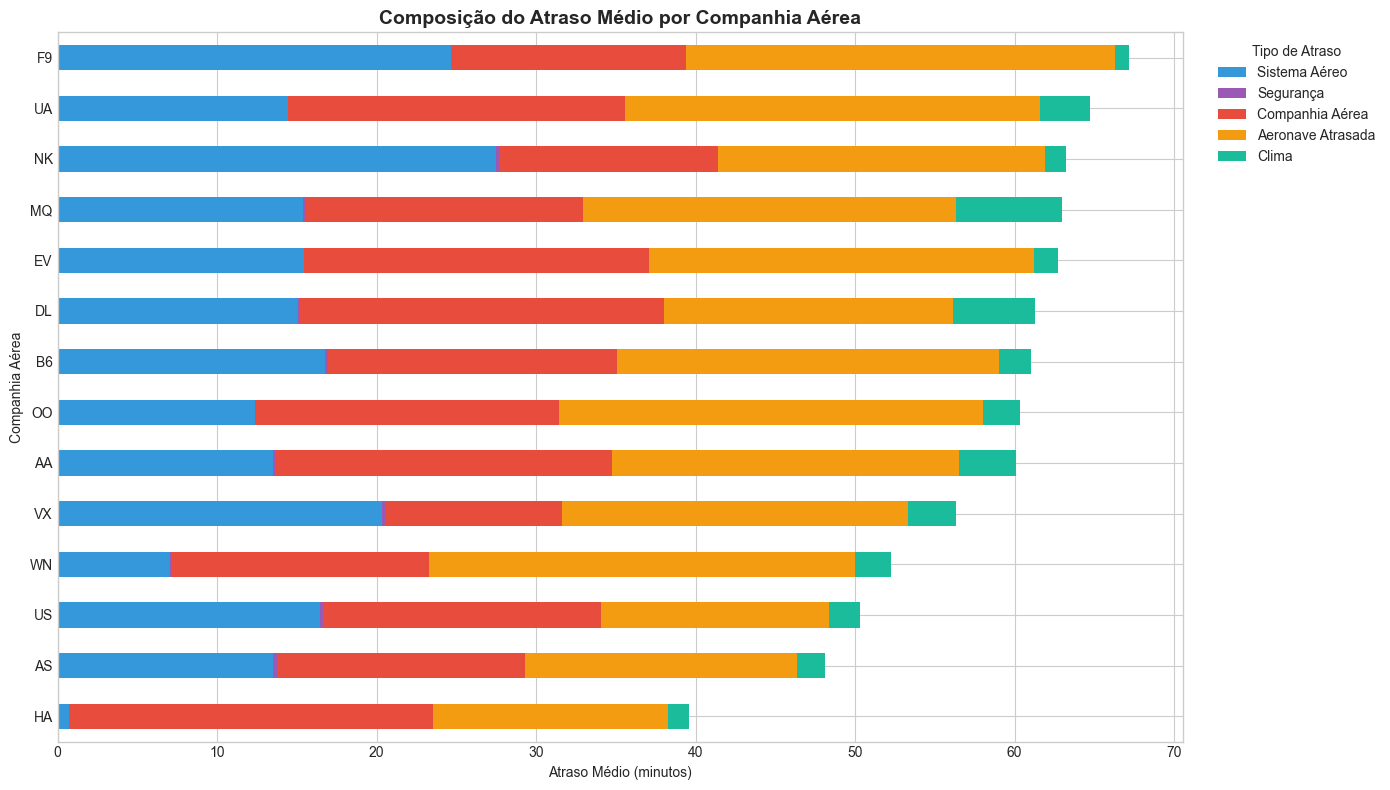


📊 ANÁLISE POR COMPANHIA (principal causa de atraso):
   HA: Principal causa = Companhia Aérea (22.79 min médio)
   AS: Principal causa = Aeronave Atrasada (17.06 min médio)
   US: Principal causa = Companhia Aérea (17.41 min médio)
   WN: Principal causa = Aeronave Atrasada (26.68 min médio)
   VX: Principal causa = Aeronave Atrasada (21.69 min médio)
   AA: Principal causa = Aeronave Atrasada (21.75 min médio)
   OO: Principal causa = Aeronave Atrasada (26.61 min médio)
   B6: Principal causa = Aeronave Atrasada (23.95 min médio)
   DL: Principal causa = Companhia Aérea (22.94 min médio)
   EV: Principal causa = Aeronave Atrasada (24.08 min médio)
   MQ: Principal causa = Aeronave Atrasada (23.40 min médio)
   NK: Principal causa = Sistema Aéreo (27.51 min médio)
   UA: Principal causa = Aeronave Atrasada (26.02 min médio)
   F9: Principal causa = Aeronave Atrasada (26.90 min médio)


In [30]:
# 5.2 Tipos de Atraso por Companhia Aérea
print('='*60)
print('TIPOS DE ATRASO POR COMPANHIA AÉREA')
print('='*60)

# Calcular média de cada tipo de atraso por companhia
airline_delay_types = df_valid.groupby('AIRLINE')[delay_types].mean()
airline_delay_types.columns = delay_labels

# Ordenar por total de atraso
airline_delay_types['Total'] = airline_delay_types.sum(axis=1)
airline_delay_types = airline_delay_types.sort_values('Total', ascending=True)
airline_delay_types = airline_delay_types.drop('Total', axis=1)

# Stacked bar chart
fig, ax = plt.subplots(figsize=(14, 8))
airline_delay_types.plot(kind='barh', stacked=True, ax=ax, color=colors_delay)
ax.set_xlabel('Atraso Médio (minutos)')
ax.set_ylabel('Companhia Aérea')
ax.set_title('Composição do Atraso Médio por Companhia Aérea', fontsize=14, fontweight='bold')
ax.legend(title='Tipo de Atraso', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../data/processed/fig_11_atraso_tipo_companhia.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 ANÁLISE POR COMPANHIA (principal causa de atraso):')
for airline in airline_delay_types.index:
    main_cause = airline_delay_types.loc[airline].idxmax()
    main_value = airline_delay_types.loc[airline].max()
    print(f'   {airline}: Principal causa = {main_cause} ({main_value:.2f} min médio)')

In [31]:
# 5.3 Análise Sazonal dos Motivos de Atraso
print('='*60)
print('ANÁLISE SAZONAL DOS MOTIVOS DE ATRASO')
print('='*60)

# Calcular média de cada tipo de atraso por mês
monthly_delay_types = df_valid.groupby('MONTH')[delay_types].mean()
monthly_delay_types.columns = delay_labels

fig = go.Figure()

for i, (col, color) in enumerate(zip(delay_labels, colors_delay)):
    fig.add_trace(go.Scatter(
        x=list(month_names.values()),
        y=monthly_delay_types[col].values,
        mode='lines+markers',
        name=col,
        line=dict(color=color, width=2),
        marker=dict(size=8)
    ))

fig.update_layout(
    title='Evolução Mensal dos Tipos de Atraso',
    xaxis_title='Mês',
    yaxis_title='Atraso Médio (minutos)',
    height=500,
    hovermode='x unified'
)
fig.show()

print('\n📊 PADRÕES SAZONAIS IDENTIFICADOS:')
for label in delay_labels:
    max_month = monthly_delay_types[label].idxmax()
    min_month = monthly_delay_types[label].idxmin()
    print(f'   {label}:')
    print(f'      Pico: {month_names[max_month]} ({monthly_delay_types.loc[max_month, label]:.2f} min)')
    print(f'      Mínimo: {month_names[min_month]} ({monthly_delay_types.loc[min_month, label]:.2f} min)')

ANÁLISE SAZONAL DOS MOTIVOS DE ATRASO



📊 PADRÕES SAZONAIS IDENTIFICADOS:
   Sistema Aéreo:
      Pico: Fevereiro (14.18 min)
      Mínimo: Julho (12.48 min)
   Segurança:
      Pico: Agosto (0.13 min)
      Mínimo: Abril (0.04 min)
   Companhia Aérea:
      Pico: Outubro (20.07 min)
      Mínimo: Janeiro (17.80 min)
   Aeronave Atrasada:
      Pico: Junho (26.40 min)
      Mínimo: Setembro (19.73 min)
   Clima:
      Pico: Fevereiro (4.32 min)
      Mínimo: Outubro (1.82 min)


In [32]:
# 5.4 Drill-down por Aeroporto (Top 10 mais movimentados)
print('='*60)
print('DRILL-DOWN: TIPOS DE ATRASO NOS TOP 10 AEROPORTOS')
print('='*60)

# Top 10 aeroportos por volume
top_10_airports = df_valid['ORIGIN_AIRPORT'].value_counts().head(10).index.tolist()

# Calcular composição de atraso para cada aeroporto
airport_delay_composition = df_valid[df_valid['ORIGIN_AIRPORT'].isin(top_10_airports)].groupby('ORIGIN_AIRPORT')[delay_types].mean()
airport_delay_composition.columns = delay_labels

# Adicionar informações do aeroporto
airport_info = df_airports.set_index('IATA_CODE')['CITY'].to_dict()
airport_delay_composition['Cidade'] = airport_delay_composition.index.map(airport_info)
airport_delay_composition = airport_delay_composition.sort_values(delay_labels, ascending=False)

# Criar gráfico
fig = px.bar(airport_delay_composition.reset_index().melt(id_vars=['ORIGIN_AIRPORT', 'Cidade'], 
                                                          value_vars=delay_labels,
                                                          var_name='Tipo_Atraso', 
                                                          value_name='Atraso_Medio'),
             x='ORIGIN_AIRPORT',
             y='Atraso_Medio',
             color='Tipo_Atraso',
             color_discrete_sequence=colors_delay,
             title='Composição do Atraso nos Top 10 Aeroportos',
             labels={'ORIGIN_AIRPORT': 'Aeroporto', 'Atraso_Medio': 'Atraso Médio (min)'},
             barmode='stack')

fig.update_layout(height=500, xaxis_tickangle=-45)
fig.show()

print('\n📊 RESUMO DOS TOP 10 AEROPORTOS:')
for airport in top_10_airports:
    city = airport_info.get(airport, 'N/A')
    total_delay = airport_delay_composition.loc[airport, delay_labels].sum()
    main_cause = airport_delay_composition.loc[airport, delay_labels].idxmax()
    print(f'   {airport} ({city}): Atraso total médio = {total_delay:.1f}min | Principal causa = {main_cause}')

DRILL-DOWN: TIPOS DE ATRASO NOS TOP 10 AEROPORTOS



📊 RESUMO DOS TOP 10 AEROPORTOS:
   ATL (Atlanta): Atraso total médio = 56.8min | Principal causa = Companhia Aérea
   ORD (Chicago): Atraso total médio = 62.7min | Principal causa = Aeronave Atrasada
   DFW (Dallas-Fort Worth): Atraso total médio = 57.6min | Principal causa = Companhia Aérea
   DEN (Denver): Atraso total médio = 55.8min | Principal causa = Aeronave Atrasada
   LAX (Los Angeles): Atraso total médio = 54.1min | Principal causa = Aeronave Atrasada
   PHX (Phoenix): Atraso total médio = 49.9min | Principal causa = Aeronave Atrasada
   SFO (San Francisco): Atraso total médio = 58.7min | Principal causa = Aeronave Atrasada
   IAH (Houston): Atraso total médio = 58.2min | Principal causa = Aeronave Atrasada
   LAS (Las Vegas): Atraso total médio = 55.7min | Principal causa = Aeronave Atrasada
   MSP (Minneapolis): Atraso total médio = 55.4min | Principal causa = Companhia Aérea


In [44]:
# 5.5 Análise de Horários Críticos
print('='*60)
print('ANÁLISE DE HORÁRIOS CRÍTICOS')
print('='*60)

# Calcular taxa de atraso e atraso médio por hora
hourly_stats = df_valid.groupby('HOUR').agg({
    'ARRIVAL_DELAY': 'mean',
    'IS_DELAYED': 'mean',
    'FLIGHT_NUMBER': 'count'
}).reset_index()
hourly_stats.columns = ['Hora', 'Atraso_Medio', 'Taxa_Atraso', 'Total_Voos']
hourly_stats['Taxa_Atraso'] = hourly_stats['Taxa_Atraso'] * 100

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=('Atraso Médio por Hora', 'Taxa de Atraso e Volume por Hora'),
                    specs=[[{"secondary_y": False}], [{"secondary_y": True}]])

# Atraso médio
fig.add_trace(go.Bar(x=hourly_stats['Hora'], y=hourly_stats['Atraso_Medio'],
                     name='Atraso Médio', marker_color='steelblue'),
              row=1, col=1)
fig.add_hline(y=0, line_dash="dash", line_color="green", row=1, col=1)
fig.add_hline(y=hourly_stats['Atraso_Medio'].mean(), line_dash="dash", line_color="red", 
              annotation_text=f"Média: {hourly_stats['Atraso_Medio'].mean():.1f}min", row=1, col=1)

# Taxa de atraso
fig.add_trace(go.Bar(x=hourly_stats['Hora'], y=hourly_stats['Taxa_Atraso'],
                     name='Taxa de Atraso (%)', marker_color='coral'),
              row=2, col=1)

# Volume de voos (eixo secundário)
fig.add_trace(go.Scatter(x=hourly_stats['Hora'], y=hourly_stats['Total_Voos'],
                         name='Volume de Voos', line=dict(color='darkgreen', width=2),
                         mode='lines+markers'),
              row=2, col=1, secondary_y=True)

fig.update_xaxes(title_text='Hora do Dia', row=2, col=1, dtick=1)
fig.update_yaxes(title_text='Atraso (min)', row=1, col=1)
fig.update_yaxes(title_text='Taxa (%)', row=2, col=1)
fig.update_yaxes(title_text='Nº Voos', row=2, col=1, secondary_y=True)
fig.update_layout(height=700, title_text='Análise de Horários Críticos', showlegend=True)
fig.show()

print('\n📊 HORÁRIOS CRÍTICOS (maior taxa de atraso):')
critical_hours = hourly_stats.nlargest(5, 'Taxa_Atraso')
for _, row in critical_hours.iterrows():
    print(f'   {int(row["Hora"]):02d}h: Taxa {row["Taxa_Atraso"]:.1f}% | Atraso médio {row["Atraso_Medio"]:.1f}min | {row["Total_Voos"]:,} voos')

print('\n📊 MELHORES HORÁRIOS (menor taxa de atraso):')
best_hours = hourly_stats.nsmallest(5, 'Taxa_Atraso')
for _, row in best_hours.iterrows():
    print(f'   {int(row["Hora"]):02d}h: Taxa {row["Taxa_Atraso"]:.1f}% | Atraso médio {row["Atraso_Medio"]:.1f}min | {row["Total_Voos"]:,} voos')

ANÁLISE DE HORÁRIOS CRÍTICOS



📊 HORÁRIOS CRÍTICOS (maior taxa de atraso):
   20h: Taxa 26.3% | Atraso médio 9.8min | 254,179.0 voos
   19h: Taxa 26.2% | Atraso médio 10.1min | 325,209.0 voos
   18h: Taxa 25.8% | Atraso médio 9.9min | 327,884.0 voos
   17h: Taxa 24.4% | Atraso médio 9.0min | 383,576.0 voos
   21h: Taxa 24.3% | Atraso médio 8.1min | 183,786.0 voos

📊 MELHORES HORÁRIOS (menor taxa de atraso):
   05h: Taxa 7.2% | Atraso médio -3.8min | 115,984.0 voos
   06h: Taxa 9.0% | Atraso médio -2.6min | 399,618.0 voos
   07h: Taxa 11.2% | Atraso médio -1.5min | 388,704.0 voos
   08h: Taxa 12.9% | Atraso médio -0.2min | 375,689.0 voos
   09h: Taxa 14.2% | Atraso médio 1.0min | 347,064.0 voos


ANÁLISE DE CANCELAMENTOS

Total de voos cancelados: 89,884 (1.54%)


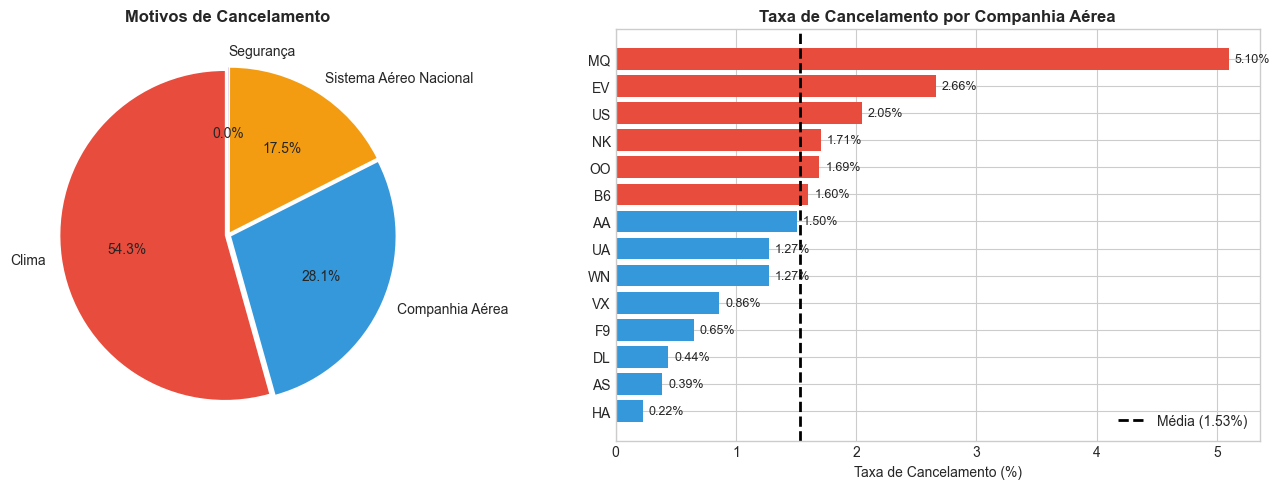


📊 MOTIVOS DE CANCELAMENTO:
   Clima: 48,851 voos (54.3%)
   Companhia Aérea: 25,262 voos (28.1%)
   Sistema Aéreo Nacional: 15,749 voos (17.5%)
   Segurança: 22 voos (0.0%)


In [45]:
# 5.6 Análise de Cancelamentos
print('='*60)
print('ANÁLISE DE CANCELAMENTOS')
print('='*60)

# Filtrar voos cancelados
df_cancelled = df[df['CANCELLED'] == 1].copy()

print(f'\nTotal de voos cancelados: {len(df_cancelled):,} ({len(df_cancelled)/len(df)*100:.2f}%)')

# Motivos de cancelamento
cancellation_reasons = {
    'A': 'Companhia Aérea',
    'B': 'Clima',
    'C': 'Sistema Aéreo Nacional',
    'D': 'Segurança'
}
df_cancelled['CANCELLATION_REASON_DESC'] = df_cancelled['CANCELLATION_REASON'].map(cancellation_reasons)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart de motivos
ax1 = axes[0]
reason_counts = df_cancelled['CANCELLATION_REASON_DESC'].value_counts()
colors_cancel = ['#e74c3c', '#3498db', '#f39c12', '#9b59b6']
ax1.pie(reason_counts, labels=reason_counts.index, colors=colors_cancel, 
        autopct='%1.1f%%', startangle=90, explode=[0.02]*len(reason_counts))
ax1.set_title('Motivos de Cancelamento', fontweight='bold')

# Cancelamentos por companhia
ax2 = axes[1]
cancel_by_airline = df.groupby('AIRLINE')['CANCELLED'].mean().sort_values(ascending=True) * 100
bars = ax2.barh(cancel_by_airline.index, cancel_by_airline.values, 
                color=[COLORS[0] if x < cancel_by_airline.mean() else '#e74c3c' for x in cancel_by_airline.values])
ax2.axvline(x=cancel_by_airline.mean(), color='black', linestyle='--', linewidth=2,
            label=f'Média ({cancel_by_airline.mean():.2f}%)')
ax2.set_xlabel('Taxa de Cancelamento (%)')
ax2.set_title('Taxa de Cancelamento por Companhia Aérea', fontweight='bold')
ax2.legend()
for bar, val in zip(bars, cancel_by_airline.values):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/fig_12_cancelamentos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 MOTIVOS DE CANCELAMENTO:')
for reason, count in reason_counts.items():
    print(f'   {reason}: {count:,} voos ({count/len(df_cancelled)*100:.1f}%)')

SAZONALIDADE DOS CANCELAMENTOS


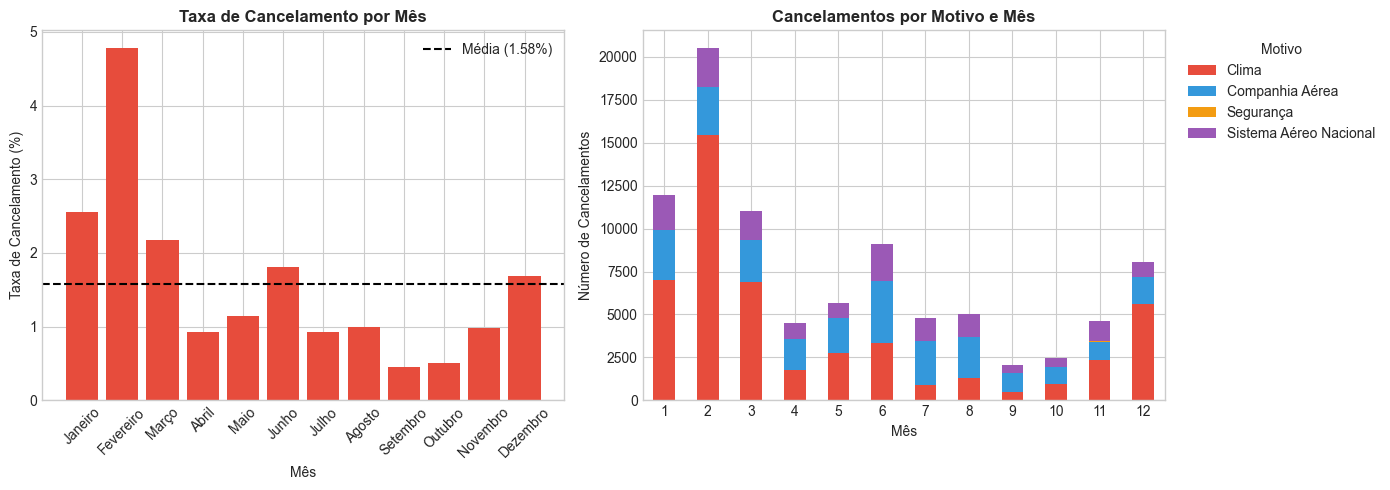


📊 MESES COM MAIOR TAXA DE CANCELAMENTO:
   Fevereiro: 4.78% (20,517 voos cancelados)
   Janeiro: 2.55% (11,982 voos cancelados)
   Março: 2.18% (11,002 voos cancelados)


In [46]:
# 5.6.1 Sazonalidade dos Cancelamentos
print('='*60)
print('SAZONALIDADE DOS CANCELAMENTOS')
print('='*60)

# Taxa de cancelamento por mês
monthly_cancellation = df.groupby('MONTH').agg({
    'CANCELLED': ['sum', 'mean'],
    'FLIGHT_NUMBER': 'count'
}).reset_index()
monthly_cancellation.columns = ['Mes', 'Total_Cancelados', 'Taxa_Cancelamento', 'Total_Voos']
monthly_cancellation['Taxa_Cancelamento'] = monthly_cancellation['Taxa_Cancelamento'] * 100
monthly_cancellation['Mes_Nome'] = monthly_cancellation['Mes'].map(month_names)

# Cancelamentos por motivo e mês
cancel_by_month_reason = df_cancelled.groupby(['MONTH', 'CANCELLATION_REASON_DESC']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taxa de cancelamento por mês
ax1 = axes[0]
bars = ax1.bar(monthly_cancellation['Mes_Nome'], monthly_cancellation['Taxa_Cancelamento'], color=COLORS[1])
ax1.axhline(y=monthly_cancellation['Taxa_Cancelamento'].mean(), color='black', linestyle='--', 
            label=f'Média ({monthly_cancellation["Taxa_Cancelamento"].mean():.2f}%)')
ax1.set_xlabel('Mês')
ax1.set_ylabel('Taxa de Cancelamento (%)')
ax1.set_title('Taxa de Cancelamento por Mês', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.legend()

# Motivos por mês (stacked)
ax2 = axes[1]
cancel_by_month_reason.plot(kind='bar', stacked=True, ax=ax2, color=colors_cancel[:len(cancel_by_month_reason.columns)])
ax2.set_xlabel('Mês')
ax2.set_ylabel('Número de Cancelamentos')
ax2.set_title('Cancelamentos por Motivo e Mês', fontweight='bold')
ax2.legend(title='Motivo', bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../data/processed/fig_13_cancelamentos_sazonalidade.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 MESES COM MAIOR TAXA DE CANCELAMENTO:')
for _, row in monthly_cancellation.nlargest(3, 'Taxa_Cancelamento').iterrows():
    print(f'   {row["Mes_Nome"]}: {row["Taxa_Cancelamento"]:.2f}% ({row["Total_Cancelados"]:,} voos cancelados)')

---
# 6. Resumo e Principais Insights

Consolidação dos principais achados da análise exploratória.

In [47]:
# 6.1 Resumo Executivo
print('='*70)
print('                    RESUMO EXECUTIVO - EDA')
print('='*70)

print('''
📊 VISÃO GERAL DO DATASET:
''')
print(f'   • Total de voos analisados: {len(df):,}')
print(f'   • Período: {df["DATE"].min().strftime("%d/%m/%Y")} a {df["DATE"].max().strftime("%d/%m/%Y")}')
print(f'   • Companhias aéreas: {df["AIRLINE"].nunique()}')
print(f'   • Aeroportos: {df["ORIGIN_AIRPORT"].nunique()} origem / {df["DESTINATION_AIRPORT"].nunique()} destino')
print(f'   • Rotas únicas: {df["ROUTE"].nunique():,}')

print('''
✈️ ATRASOS (>= 15 minutos):
''')
print(f'   • Taxa geral de atraso: {df_valid["IS_DELAYED"].mean()*100:.2f}%')
print(f'   • Atraso médio (quando atrasado): {df_valid[df_valid["IS_DELAYED"]==1]["ARRIVAL_DELAY"].mean():.1f} minutos')
print(f'   • Atraso mediano: {df_valid["ARRIVAL_DELAY"].median():.1f} minutos')

print('''
🏢 COMPANHIAS AÉREAS:
''')
best_airline = airline_delay.sort_values('Taxa_Atraso').index[0]
worst_airline = airline_delay.sort_values('Taxa_Atraso').index[-1]
print(f'   • Melhor desempenho: {best_airline} ({airline_delay.loc[best_airline, "Taxa_Atraso"]:.1f}% de atrasos)')
print(f'   • Pior desempenho: {worst_airline} ({airline_delay.loc[worst_airline, "Taxa_Atraso"]:.1f}% de atrasos)')

print('''
🛫 AEROPORTOS CRÍTICOS (min. 5000 voos):
''')
print(f'   • Maior taxa de atraso (origem): {origin_stats_filtered.index[0]} ({origin_stats_filtered.iloc[0]["Taxa_Atraso"]:.1f}%)')
print(f'   • Maior taxa de atraso (destino): {dest_stats_filtered.index[0]} ({dest_stats_filtered.iloc[0]["Taxa_Atraso"]:.1f}%)')

print('''
⏰ PADRÕES TEMPORAIS:
''')
print(f'   • Horário mais crítico: {int(critical_hours.iloc[0]["Hora"]):02d}h ({critical_hours.iloc[0]["Taxa_Atraso"]:.1f}% de atrasos)')
print(f'   • Melhor horário: {int(best_hours.iloc[0]["Hora"]):02d}h ({best_hours.iloc[0]["Taxa_Atraso"]:.1f}% de atrasos)')
worst_day = df_valid.groupby('DAY_NAME')['IS_DELAYED'].mean().sort_values(ascending=False).index[0]
best_day = df_valid.groupby('DAY_NAME')['IS_DELAYED'].mean().sort_values().index[0]
print(f'   • Dia mais problemático: {worst_day}')
print(f'   • Melhor dia: {best_day}')

print('''
🔍 CAUSAS DOS ATRASOS:
''')
main_cause = delay_totals.idxmax()
main_cause_pct = delay_totals[main_cause] / delay_totals.sum() * 100
print(f'   • Principal causa: {main_cause} ({main_cause_pct:.1f}% do tempo total de atraso)')
print(f'   • Atraso por clima é mais comum em: {month_names[monthly_delay_types["Clima"].idxmax()]}')

print('''
❌ CANCELAMENTOS:
''')
print(f'   • Taxa de cancelamento: {df["CANCELLED"].mean()*100:.2f}%')
print(f'   • Principal motivo: {reason_counts.index[0]} ({reason_counts.iloc[0]/len(df_cancelled)*100:.1f}%)')

print('\n' + '='*70)

                    RESUMO EXECUTIVO - EDA

📊 VISÃO GERAL DO DATASET:

   • Total de voos analisados: 5,819,079
   • Período: 01/01/2015 a 31/12/2015
   • Companhias aéreas: 14
   • Aeroportos: 628 origem / 629 destino
   • Rotas únicas: 8,609

✈️ ATRASOS (>= 15 minutos):

   • Taxa geral de atraso: 18.56%
   • Atraso médio (quando atrasado): 58.9 minutos
   • Atraso mediano: -5.0 minutos

🏢 COMPANHIAS AÉREAS:

   • Melhor desempenho: Hawaiian Airlines Inc. (11.0% de atrasos)
   • Pior desempenho: Spirit Air Lines (30.0% de atrasos)

🛫 AEROPORTOS CRÍTICOS (min. 5000 voos):

   • Maior taxa de atraso (origem): HPN (25.0%)
   • Maior taxa de atraso (destino): LGA (26.0%)

⏰ PADRÕES TEMPORAIS:

   • Horário mais crítico: 20h (26.3% de atrasos)
   • Melhor horário: 05h (7.2% de atrasos)
   • Dia mais problemático: Quinta
   • Melhor dia: Sábado

🔍 CAUSAS DOS ATRASOS:

   • Principal causa: Aeronave Atrasada (39.8% do tempo total de atraso)
   • Atraso por clima é mais comum em: Fevereiro



In [48]:
# 6.2 Salvando Datasets Preparados
print('='*60)
print('SALVANDO DATASETS PARA PRÓXIMAS ETAPAS')
print('='*60)

# Salvar dataset enriquecido (voos válidos para modelagem)
df_valid.to_parquet('../data/processed/flights_processed.parquet', index=False)
print(f'\n✅ Dataset processado salvo: flights_processed.parquet')
print(f'   Shape: {df_valid.shape}')

# Salvar dataset completo com todas as features
df.to_parquet('../data/processed/flights_complete.parquet', index=False)
print(f'\n✅ Dataset completo salvo: flights_complete.parquet')
print(f'   Shape: {df.shape}')

# Salvar estatísticas por aeroporto para possível uso em dashboard
origin_stats.to_csv('../data/processed/airport_origin_stats.csv')
dest_stats.to_csv('../data/processed/airport_dest_stats.csv')
print(f'\n✅ Estatísticas de aeroportos salvas')

# Salvar estatísticas por companhia
airline_delay.to_csv('../data/processed/airline_stats.csv')
print(f'\n✅ Estatísticas de companhias aéreas salvas')

print('\n' + '='*60)
print('EDA CONCLUÍDA COM SUCESSO!')
print('='*60)

SALVANDO DATASETS PARA PRÓXIMAS ETAPAS

✅ Dataset processado salvo: flights_processed.parquet
   Shape: (5729195, 50)

✅ Dataset completo salvo: flights_complete.parquet
   Shape: (5819079, 51)

✅ Estatísticas de aeroportos salvas

✅ Estatísticas de companhias aéreas salvas

EDA CONCLUÍDA COM SUCESSO!


---
# 7. Próximos Passos

## Modelagem Supervisionada (Próximo Notebook)
- **Classificação**: Prever se um voo vai atrasar (>= 15 min) ou não
- **Regressão**: Prever o tempo de atraso em minutos
- Features candidatas identificadas:
  - Temporais: MONTH, DAY_OF_WEEK, HOUR, PERIOD
  - Operacionais: AIRLINE, ORIGIN_AIRPORT, DESTINATION_AIRPORT, DISTANCE
  - Derivadas: ROUTE, DISTANCE_CATEGORY

## Modelagem Não Supervisionada
- **Clusterização**: Agrupar aeroportos ou rotas por perfil de atraso
- **PCA**: Redução de dimensionalidade para visualização

## Insights Adicionais a Explorar
- Impacto de feriados nos atrasos
- Análise de conexões (atrasos em cascata)
- Mapas geográficos de rotas problemáticas
- Dashboard interativo para visualização